In [2]:
import os
import clip
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = "cuda"

# --- Load CLIP ---
print("Loading CLIP model...")
model, preprocess = clip.load("ViT-L/14", device=device)
model.eval()
print(f"Using: {torch.cuda.get_device_name(0)}")

Loading CLIP model...
Using: NVIDIA RTX A6000


In [25]:
import os

base_path = "dataset/wbirds/0.5pct"

class_0_path = os.path.join(base_path, "0")
class_1_path = os.path.join(base_path, "1")

len_0 = len(os.listdir(class_0_path))
len_1 = len(os.listdir(class_1_path))

print("Length of 0.5pct/0:", len_0)
print("Length of 0.5pct/1:", len_1)

Length of 0.5pct/0: 3530
Length of 0.5pct/1: 1063


In [ ]:
base = "dataset/wbirds"

def fix_copy_filenames(folder):
    renamed = 0
    label_subdirs = [d for d in ["0", "1"] if os.path.isdir(os.path.join(folder, d))]
    
    dirs_to_scan = []
    if label_subdirs:
        for label_folder in label_subdirs:
            dirs_to_scan.append(os.path.join(folder, label_folder))
    else:
        dirs_to_scan.append(folder)
    
    for subdir in dirs_to_scan:
        for fname in sorted(os.listdir(subdir)):
            if not fname.endswith(".jpg"):
                continue
            if "copy" in fname.lower():
                new_fname = fname.replace(" copy", "").replace(" Copy", "")
                old_path  = os.path.join(subdir, fname)
                new_path  = os.path.join(subdir, new_fname)
                if not os.path.exists(new_path):  # avoid overwriting
                    os.rename(old_path, new_path)
                    print(f"Renamed: {fname} → {new_fname}")
                    renamed += 1
                else:
                    print(f"Skipped (already exists): {fname}")
    
    print(f"\nTotal renamed: {renamed}")

# Usage
fix_copy_filenames(f"{base}/0.5pct")

Skipped (already exists): 10015_0_1 copy.jpg
Skipped (already exists): 10772_0_1 copy.jpg
Skipped (already exists): 1087_0_1 copy.jpg
Skipped (already exists): 10913_0_1 copy.jpg
Skipped (already exists): 11355_0_1 copy.jpg
Skipped (already exists): 1759_0_1 copy.jpg
Skipped (already exists): 2154_0_1 copy.jpg
Skipped (already exists): 2342_0_1 copy.jpg
Skipped (already exists): 3930_0_1 copy.jpg
Skipped (already exists): 4632_0_1 copy.jpg
Skipped (already exists): 5315_0_1 copy.jpg
Skipped (already exists): 6435_0_1 copy.jpg
Skipped (already exists): 6475_0_1 copy.jpg
Skipped (already exists): 7814_0_1 copy.jpg
Skipped (already exists): 8217_0_1 copy.jpg
Skipped (already exists): 9234_0_1 copy.jpg

Total renamed: 0


In [33]:
def remove_copy_files(folder):
    removed = 0
    label_subdirs = [d for d in ["0", "1"] if os.path.isdir(os.path.join(folder, d))]
    
    dirs_to_scan = []
    if label_subdirs:
        for label_folder in label_subdirs:
            dirs_to_scan.append(os.path.join(folder, label_folder))
    else:
        dirs_to_scan.append(folder)
    
    for subdir in dirs_to_scan:
        for fname in sorted(os.listdir(subdir)):
            if not fname.endswith(".jpg"):
                continue
            if "copy" in fname.lower():
                path = os.path.join(subdir, fname)
                os.remove(path)
                print(f"Deleted: {fname}")
                removed += 1
    
    print(f"\nTotal deleted: {removed}")

# Usage
remove_copy_files(f"{base}/0.5pct")

Deleted: 10015_0_1 copy.jpg
Deleted: 10772_0_1 copy.jpg
Deleted: 1087_0_1 copy.jpg
Deleted: 10913_0_1 copy.jpg
Deleted: 11355_0_1 copy.jpg
Deleted: 1759_0_1 copy.jpg
Deleted: 2154_0_1 copy.jpg
Deleted: 2342_0_1 copy.jpg
Deleted: 3930_0_1 copy.jpg
Deleted: 4632_0_1 copy.jpg
Deleted: 5315_0_1 copy.jpg
Deleted: 6435_0_1 copy.jpg
Deleted: 6475_0_1 copy.jpg
Deleted: 7814_0_1 copy.jpg
Deleted: 8217_0_1 copy.jpg
Deleted: 9234_0_1 copy.jpg

Total deleted: 16


In [ ]:
class WBirds(Dataset):
    def __init__(self, folder, transform, mode="all"):
        self.transform = transform
        self.samples = []

        if mode == "train":
            #  ONLY load from 0 and 1 folders
            for label_folder in ["0", "1"]:
                subdir = os.path.join(folder, label_folder)
                if not os.path.isdir(subdir):
                    continue

                for fname in os.listdir(subdir):
                    if not fname.endswith(".jpg"):
                        continue

                    parts = fname.replace(".jpg", "").split("_")
                    if len(parts) < 3:
                        continue

                    label = int(parts[1])
                    background = int(parts[2])

                    path = os.path.join(subdir, fname)
                    self.samples.append((path, label, background))

        else:
            #  load everything (for test/valid/align/conflict)
            for root, _, files in os.walk(folder):
                for fname in files:
                    if not fname.endswith(".jpg"):
                        continue

                    parts = fname.replace(".jpg", "").split("_")
                    if len(parts) < 3:
                        continue

                    label = int(parts[1])
                    background = int(parts[2])

                    path = os.path.join(root, fname)
                    self.samples.append((path, label, background))

        print(f"{folder}: {len(self.samples)} samples loaded")

    def __len__(self): 
        return len(self.samples) 
        
    def __getitem__(self, idx): 
        path, label, background = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return img, label, background


In [121]:
import torch
from torch.utils.data import DataLoader

def extract(loader):
    all_embs, all_label, all_background = [], [], []
    with torch.no_grad():
        for imgs, label, background in loader:
            embs = model.encode_image(imgs.to(device))
            all_embs.append(embs.cpu())
            all_label.append(label)
            all_background.append(background)
    return torch.cat(all_embs), torch.cat(all_label).numpy(), torch.cat(all_background).numpy()


base = "dataset/wbirds"

print("Extracting test...") 
test_ds = WBirds(f"{base}/test", preprocess) 
test_embs, test_labels, test_groups = extract(
    DataLoader(test_ds, batch_size=512, num_workers=4) 
)

print("Extracting valid...")
valid_ds = WBirds(f"{base}/0.5pct/valid", preprocess)   
valid_embs, valid_labels, valid_groups = extract(
    DataLoader(valid_ds, batch_size=512, num_workers=4)
)

print("Extracting train (0.5pct)...")
train_ds = WBirds(f"{base}/0.5pct", preprocess, mode="train")
train_embs, train_labels, train_groups = extract(
    DataLoader(train_ds, batch_size=512, num_workers=4)
)

print("Extracting align...")
align_ds = WBirds(f"{base}/0.5pct/align", preprocess)
align_embs, align_labels, align_groups = extract(
    DataLoader(align_ds, batch_size=512, num_workers=4)
)

print("Extracting conflict...")
conflict_ds = WBirds(f"{base}/0.5pct/conflict", preprocess)
conflict_embs, conflict_labels, conflict_groups = extract(
    DataLoader(conflict_ds, batch_size=512, num_workers=4)
)

print("Extracting 0...") 
ds_0 = WBirds(f"{base}/0.5pct/0", preprocess) 
embs_0, labels_0, groups_0 = extract(
    DataLoader(ds_0, batch_size=512, num_workers=4) 
)

print("Extracting 1...") 
ds_1 = WBirds(f"{base}/0.5pct/1", preprocess) 
embs_1, labels_1, groups_1 = extract(
    DataLoader(ds_1, batch_size=512, num_workers=4) 
)

Extracting test...
dataset/wbirds/test: 5794 samples loaded


Extracting valid...
dataset/wbirds/0.5pct/valid: 1199 samples loaded
Extracting train (0.5pct)...
dataset/wbirds/0.5pct: 4577 samples loaded
Extracting align...
dataset/wbirds/0.5pct/align: 4571 samples loaded
Extracting conflict...
dataset/wbirds/0.5pct/conflict: 22 samples loaded
Extracting 0...
dataset/wbirds/0.5pct/0: 3514 samples loaded
Extracting 1...
dataset/wbirds/0.5pct/1: 1063 samples loaded


In [122]:
os.makedirs("0.5pct/embeddings", exist_ok=True)

# test / valid
torch.save(test_embs,  "0.5pct/embeddings/test_embs.pt")
torch.save(valid_embs, "0.5pct/embeddings/valid_embs.pt")

np.save("0.5pct/embeddings/test_labels.npy",  test_labels)
np.save("0.5pct/embeddings/test_groups.npy", test_groups)

np.save("0.5pct/embeddings/valid_labels.npy",  valid_labels)
np.save("0.5pct/embeddings/valid_groups.npy", valid_groups)

# train
torch.save(train_embs, "0.5pct/embeddings/train_embs.pt")
np.save("0.5pct/embeddings/train_labels.npy",  train_labels)
np.save("0.5pct/embeddings/train_groups.npy", train_groups)

# 1
torch.save(embs_1, "0.5pct/embeddings/embs_1.pt")
np.save("0.5pct/embeddings/labels_1.npy",  labels_1)
np.save("0.5pct/embeddings/groups_1.npy", groups_1)

# 0
torch.save(embs_0, "0.5pct/embeddings/embs_0.pt")
np.save("0.5pct/embeddings/labels_0.npy",  labels_0)
np.save("0.5pct/embeddings/groups_0.npy", groups_0)

# align / conflict
torch.save(align_embs,    "0.5pct/embeddings/align_embs.pt")
torch.save(conflict_embs, "0.5pct/embeddings/conflict_embs.pt")

np.save("0.5pct/embeddings/align_labels.npy",    align_labels)
np.save("0.5pct/embeddings/align_groups.npy",    align_groups)

np.save("0.5pct/embeddings/conflict_labels.npy", conflict_labels)
np.save("0.5pct/embeddings/conflict_groups.npy", conflict_groups)

print("All embeddings saved!")

All embeddings saved!


In [123]:
print("\n--- Bias check (WBirds) ---")

for split, labels, groups in [
    ("train", train_labels, train_groups),
    ("valid", valid_labels, valid_groups),
    ("test",  test_labels,  test_groups),
    ("align",  align_labels,  align_groups),
    ("conflict",  conflict_labels,  conflict_groups),
    ("0",  labels_0, groups_0),
    ("1",  labels_1, groups_1),

]:
    print(f"\n{split} (n={len(labels)}):")

    for g, gname in [(0, "align"), (1, "conflict")]:
        mask = groups == g
        if mask.sum() == 0:
            continue

        # distribution of labels inside each group
        class0_pct = (labels[mask] == 0).mean() * 100
        class1_pct = (labels[mask] == 1).mean() * 100

        print(f"  {gname}:")
        print(f"    class 0: {class0_pct:.1f}%")
        print(f"    class 1: {class1_pct:.1f}%")
        print(f"    n = {mask.sum()}")


--- Bias check (WBirds) ---

train (n=4577):
  align:
    class 0: 99.8%
    class 1: 0.2%
    n = 3504
  conflict:
    class 0: 1.5%
    class 1: 98.5%
    n = 1073

valid (n=1199):
  align:
    class 0: 77.8%
    class 1: 22.2%
    n = 600
  conflict:
    class 0: 77.8%
    class 1: 22.2%
    n = 599

test (n=5794):
  align:
    class 0: 77.8%
    class 1: 22.2%
    n = 2897
  conflict:
    class 0: 77.8%
    class 1: 22.2%
    n = 2897

align (n=4571):
  align:
    class 0: 100.0%
    class 1: 0.0%
    n = 3498
  conflict:
    class 0: 1.5%
    class 1: 98.5%
    n = 1073

conflict (n=22):
  align:
    class 0: 0.0%
    class 1: 100.0%
    n = 6
  conflict:
    class 0: 100.0%
    class 1: 0.0%
    n = 16

0 (n=3514):
  align:
    class 0: 100.0%
    class 1: 0.0%
    n = 3498
  conflict:
    class 0: 100.0%
    class 1: 0.0%
    n = 16

1 (n=1063):
  align:
    class 0: 0.0%
    class 1: 100.0%
    n = 6
  conflict:
    class 0: 0.0%
    class 1: 100.0%
    n = 1057


In [124]:
import torch
import numpy as np

train_embs = torch.load("0.5pct/embeddings/train_embs.pt").float()
test_embs  = torch.load("0.5pct/embeddings/test_embs.pt").float()
valid_embs = torch.load("0.5pct/embeddings/valid_embs.pt").float()
align_embs = torch.load("0.5pct/embeddings/align_embs.pt").float()
conflict_embs = torch.load("0.5pct/embeddings/conflict_embs.pt").float()
embs_1 = torch.load("0.5pct/embeddings/embs_1.pt").float()
embs_0= torch.load("0.5pct/embeddings/embs_0.pt").float()



train_labels = np.load("0.5pct/embeddings/train_labels.npy")
train_groups = np.load("0.5pct/embeddings/train_groups.npy")

test_labels = np.load("0.5pct/embeddings/test_labels.npy")
test_groups = np.load("0.5pct/embeddings/test_groups.npy")

valid_labels = np.load("0.5pct/embeddings/valid_labels.npy")
valid_groups = np.load("0.5pct/embeddings/valid_groups.npy")

align_labels = np.load("0.5pct/embeddings/align_labels.npy")
align_groups = np.load("0.5pct/embeddings/align_groups.npy")

conflict_labels = np.load("0.5pct/embeddings/conflict_labels.npy")
conflict_groups = np.load("0.5pct/embeddings/conflict_groups.npy")

labels_1 = np.load("0.5pct/embeddings/labels_1.npy")
groups_1 = np.load("0.5pct/embeddings/groups_1.npy")

labels_0 = np.load("0.5pct/embeddings/labels_0.npy")
groups_0 = np.load("0.5pct/embeddings/groups_0.npy")

In [125]:
print(train_embs.shape)
print(test_embs.shape)
print(valid_embs.shape)
print(align_embs.shape)
print(conflict_embs.shape)
print(embs_0.shape)
print(embs_1.shape)



import os

base_path = "dataset/wbirds"

align_path = os.path.join(base_path, "0.5pct/align")
conflict_path = os.path.join(base_path, "0.5pct/conflict")
test_path = os.path.join(base_path, "test")
valid_path = os.path.join(base_path, "0.5pct/valid")
path_0 = os.path.join(base_path, "0.5pct/0")
path_1 = os.path.join(base_path, "0.5pct/1")

train = len(os.listdir(path_0))+len(os.listdir(path_1))
align = len(os.listdir(align_path+'/0'))+len(os.listdir(align_path+'/1'))
conflict = len(os.listdir(conflict_path+'/0'))+len(os.listdir(conflict_path+'/1'))
test = len(os.listdir(test_path+'/0'))+len(os.listdir(test_path+'/1'))
valid = len(os.listdir(valid_path))
len_0 = len(os.listdir(path_0))
len_1 = len(os.listdir(path_1))


print('\n\n')
print("Length of train:", train)
print("Length of test:", test)
print("Length of 0.5pct/valid:", valid)
print("Length of 0.5pct/align:", align)
print("Length of 0.5pct/conflict:", conflict)
print("Length of 0.5pct/0:", len_0)
print("Length of 0.5pct/1:", len_1)

torch.Size([4577, 768])
torch.Size([5794, 768])
torch.Size([1199, 768])
torch.Size([4571, 768])
torch.Size([22, 768])
torch.Size([3514, 768])
torch.Size([1063, 768])



Length of train: 4577
Length of test: 5794
Length of 0.5pct/valid: 1199
Length of 0.5pct/align: 4571
Length of 0.5pct/conflict: 22
Length of 0.5pct/0: 3514
Length of 0.5pct/1: 1063


Running t-SNE for train (4577 points)...
Running t-SNE for test (5794 points)...


Exception ignored in: <function _ConnectionBase.__del__ at 0x7b4ab749eef0>
Traceback (most recent call last):
  File "/data/b23_chirag_bhutra/anaconda3/envs/clipenv/lib/python3.10/multiprocessing/connection.py", line 132, in __del__
    self._close()
  File "/data/b23_chirag_bhutra/anaconda3/envs/clipenv/lib/python3.10/multiprocessing/connection.py", line 361, in _close
Traceback (most recent call last):
  File "/data/b23_chirag_bhutra/anaconda3/envs/clipenv/lib/python3.10/multiprocessing/queues.py", line 239, in _feed
    reader_close()
  File "/data/b23_chirag_bhutra/anaconda3/envs/clipenv/lib/python3.10/multiprocessing/connection.py", line 177, in close
    self._close()
  File "/data/b23_chirag_bhutra/anaconda3/envs/clipenv/lib/python3.10/multiprocessing/connection.py", line 361, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


Running t-SNE for valid (1199 points)...
Running t-SNE for align (4571 points)...
Running t-SNE for conflict (22 points)...
Running t-SNE for embs_0 (3514 points)...
Running t-SNE for embs_1 (1063 points)...
Saved tsne_all_splits.png


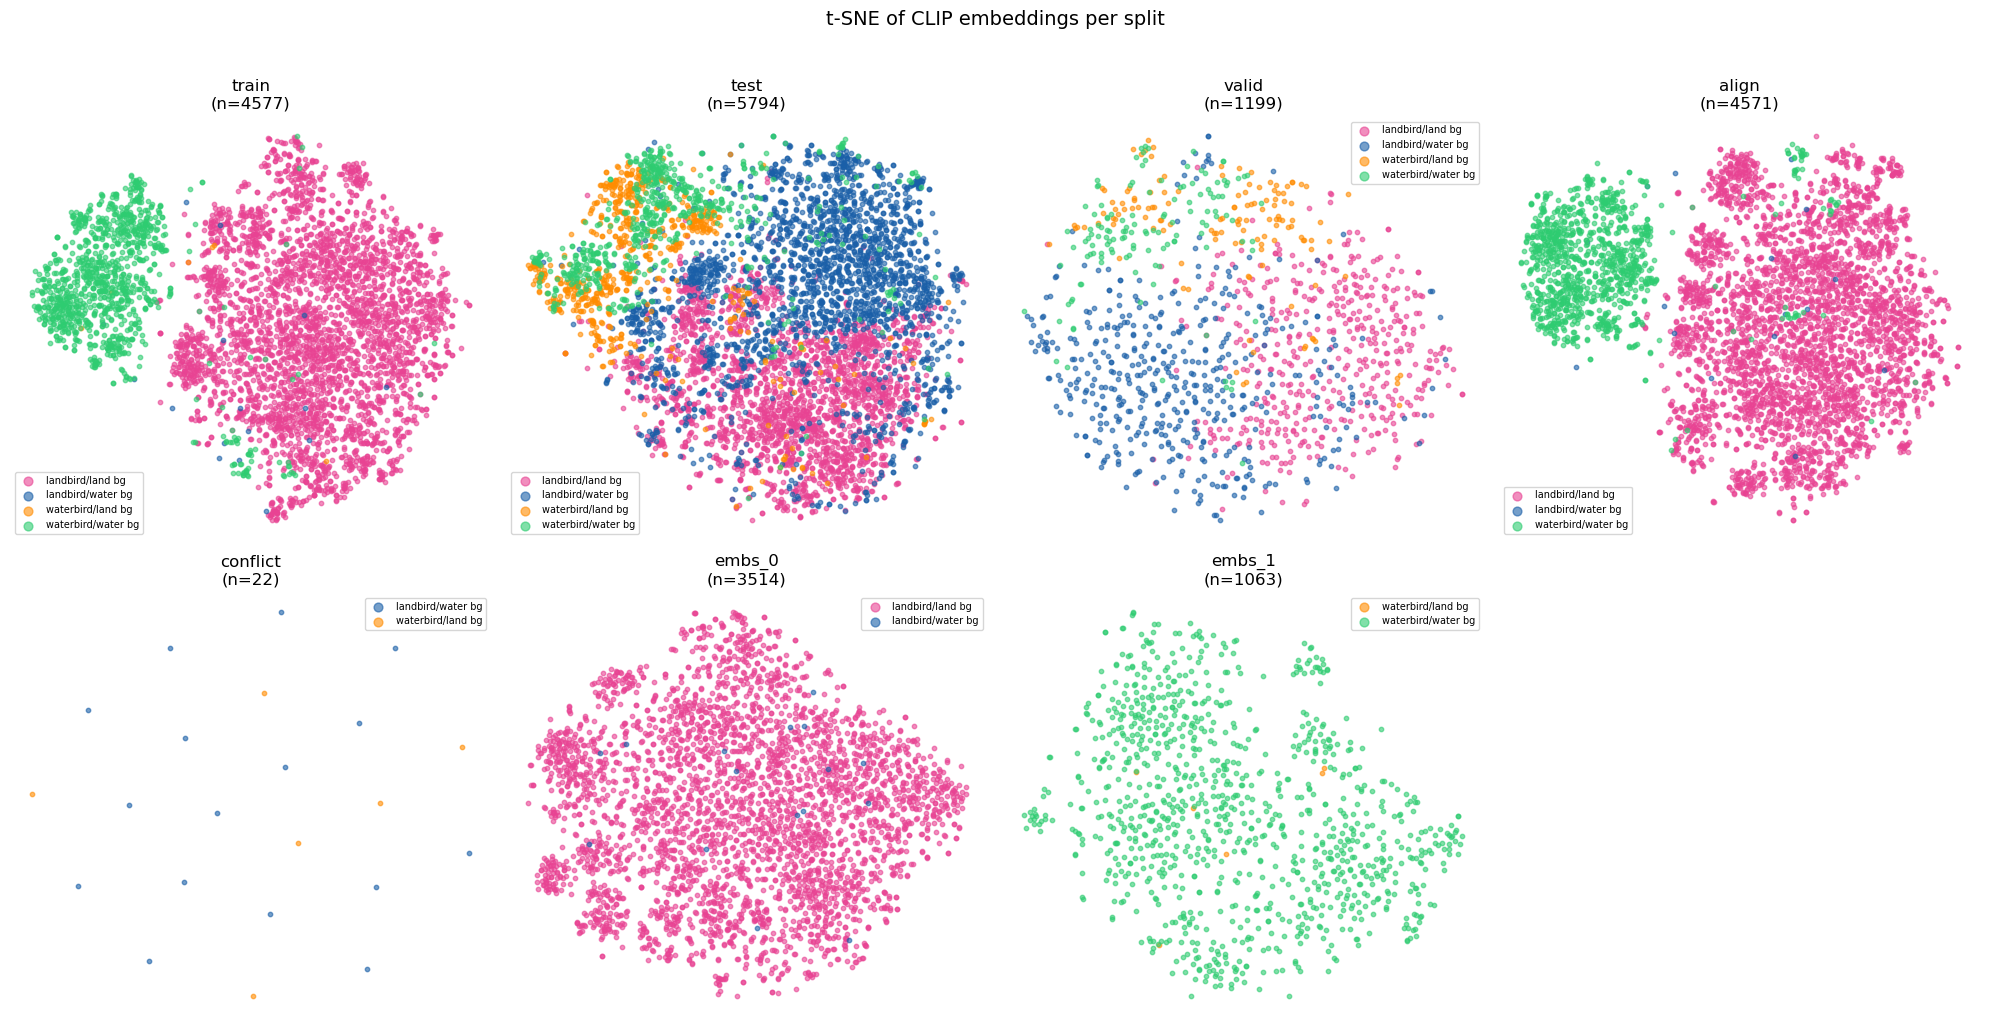

In [126]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

group_names = {0: "landbird/land bg",   1: "landbird/water bg",
               2: "waterbird/land bg",  3: "waterbird/water bg"}

colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

splits = [
    ("train",    train_embs.numpy(), train_labels, train_groups),
    ("test",     test_embs.numpy(),     test_labels,     test_groups),
    ("valid",    valid_embs.numpy(), valid_labels, valid_groups),
    ("align",    align_embs.numpy(), align_labels, align_groups),
    ("conflict", conflict_embs.numpy(), conflict_labels, conflict_groups),
    ("embs_0",    embs_0.numpy(), labels_0, groups_0),
    ("embs_1", embs_1.numpy(), labels_1, groups_1)
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()  # ← flatten to 1D

for ax, (name, embs, label, background) in zip(axes_flat, splits):
    np.random.seed(42)
    n = len(embs)
    idx = np.random.choice(len(embs), n, replace=False)
    embs_sub      = embs[idx]
    label_sub     = label[idx]
    background_sub = background[idx]
    group_sub     = label_sub * 2 + background_sub

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs_sub)

    for g, gname in group_names.items():
        mask = group_sub == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=10, alpha=0.6)

    ax.set_title(f"{name}\n(n={n})", fontsize=12)
    ax.legend(fontsize=7, markerscale=2)
    ax.axis("off")

# Hide the unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of CLIP embeddings per split", fontsize=14, y=1.02)
plt.tight_layout()
os.makedirs("0.5pct/tsne", exist_ok=True)
plt.savefig("0.5pct/tsne/tsne_all_splits.png", dpi=150, bbox_inches="tight")
print("Saved tsne_all_splits.png")

In [127]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs("0.5pct/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

splits = [
    ("train",    train_embs.numpy(),    train_labels,    train_groups),
    ("test",     test_embs.numpy(),     test_labels,     test_groups),
    ("valid",    valid_embs.numpy(),    valid_labels,    valid_groups),
    ("align",    align_embs.numpy(),    align_labels,    align_groups),
    ("conflict", conflict_embs.numpy(), conflict_labels, conflict_groups),
    ("embs_0",   embs_0.numpy(),        labels_0,        groups_0),
    ("embs_1",   embs_1.numpy(),        labels_1,        groups_1)
]

for split_name, embs, label, background in splits:
    np.random.seed(42)
    n = len(embs)
    idx            = np.random.choice(n, n, replace=False)
    embs_sub       = embs[idx]
    label_sub      = label[idx]
    background_sub = background[idx]
    group_sub      = label_sub * 2 + background_sub

    print(f"Running t-SNE for {split_name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs_sub)

    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group_sub == g
        if mask.sum() == 0:
            continue
        plt.scatter(e2d[mask, 0], e2d[mask, 1],
                    c=colors[g], label=gname, s=15, alpha=0.7)

    plt.title(f"t-SNE — {split_name} (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"0.5pct/tsne/tsne_{split_name}.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{split_name}.png")

print("\nAll plots saved!")

Running t-SNE for train (4577 points)...


Saved tsne_train.png
Running t-SNE for test (5794 points)...
Saved tsne_test.png
Running t-SNE for valid (1199 points)...
Saved tsne_valid.png
Running t-SNE for align (4571 points)...
Saved tsne_align.png
Running t-SNE for conflict (22 points)...
Saved tsne_conflict.png
Running t-SNE for embs_0 (3514 points)...
Saved tsne_embs_0.png
Running t-SNE for embs_1 (1063 points)...
Saved tsne_embs_1.png

All plots saved!


# Debiasing Embeddings

In [128]:
# Check how spread out each group is
for g, name in group_names.items():
    mask = train_groups == g
    group = train_embs[mask]
    print(f"{name:25s}  n={mask.sum():5d}  "
          f"mean_norm={group.norm(dim=-1).mean():.3f}  "
          f"intra_sim={( (group/group.norm(dim=-1,keepdim=True)) @ (group/group.norm(dim=-1,keepdim=True)).T ).mean():.3f}")

landbird/land bg           n= 3504  mean_norm=18.055  intra_sim=0.673
landbird/water bg          n= 1073  mean_norm=18.197  intra_sim=0.647
waterbird/land bg          n=    0  mean_norm=nan  intra_sim=nan
waterbird/water bg         n=    0  mean_norm=nan  intra_sim=nan


## Similarity Threshold = 0.8

In [129]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.80
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3514, 768])
waterbird: torch.Size([1063, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3514, 1063])
mean=0.600  max=0.881  min=0.218

Pairs with sim > 0.8: 531
sim range: 0.800 - 0.881
mean sim of selected pairs: 0.813
0.00 minutes


In [133]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.8).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.8): 531

Total pairs: 1061
  push (landbird↔waterbird):                531
  pull (landbird↔landbird + water↔water):   530
Before training:
  push_sim(landbird↔waterbird):     0.813
  pull_sim(landbird↔landbird):      0.669
  pull_sim(waterbird↔waterbird):    0.646

Training...
  epoch   0  loss=0.3892  push_sim=0.819  pull_landbird=0.690  pull_waterbird=0.668  W_diff=0.00023
  epoch  10  loss=0.2892  push_sim=0.824  pull_landbird=0.787  pull_waterbird=0.783  W_diff=0.00164
  epoch  20  loss=0.2008  push_sim=0.689  pull_landbird=0.750  pull_waterbird=0.759  W_diff=0.00254
  epoch  30  loss=0.1412  push_sim=0.606  pull_landbird=0.747  pull_waterbird=0.753  W_diff=0.00315
  epoch  40  loss=0.1406  push_sim=0.579  pull_landbird=0.746  pull_waterbird=0.754  W_diff=0.00336
Done!
0.1 minutes


In [135]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.8: {(sim_before_flat>0.8).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.8: {(sim_after_flat>0.8).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.600  max=0.881  >0.8: 531
  AFTER:  mean=0.499  max=0.888  >0.8: 2089

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.672  min=0.220
  AFTER:  mean=0.749  min=0.252

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.647  min=0.299
  AFTER:  mean=0.754  min=0.140
W_diff from identity: 0.00339


In [136]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
print("Saved!")

Saved!


In [137]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")
print("Saved!")

Saved!


In [138]:
train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj_push_pull(0.8).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj_push_pull(0.8).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj_push_pull(0.8).pt")

In [139]:
print(f"train_proj: {train_proj.shape}") 
print(f"test_proj:  {test_proj.shape}")  
print(f"valid_proj: {valid_proj.shape}") 

train_proj: torch.Size([4577, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 74.6%
  landbird/land bg: 99.4%
  landbird/water bg: 47.0%
  waterbird/land bg: 59.4%
  waterbird/water bg: 99.2%
  worst: 47.0%  best: 99.4%  gap: 52.4%

  DEBIASED (linear push)
Overall accuracy: 71.0%
  landbird/land bg: 98.9%
  landbird/water bg: 37.8%
  waterbird/land bg: 60.9%
  waterbird/water bg: 99.2%
  worst: 37.8%  best: 99.2%  gap: 61.5%


Running t-SNE for train (proj) (4577 points)...
Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4571 points)...
Running t-SNE for conflict (proj) (22 points)...
Running t-SNE for landbird (proj) (3514 points)...
Running t-SNE for waterbird (proj) (1063 points)...
Saved!


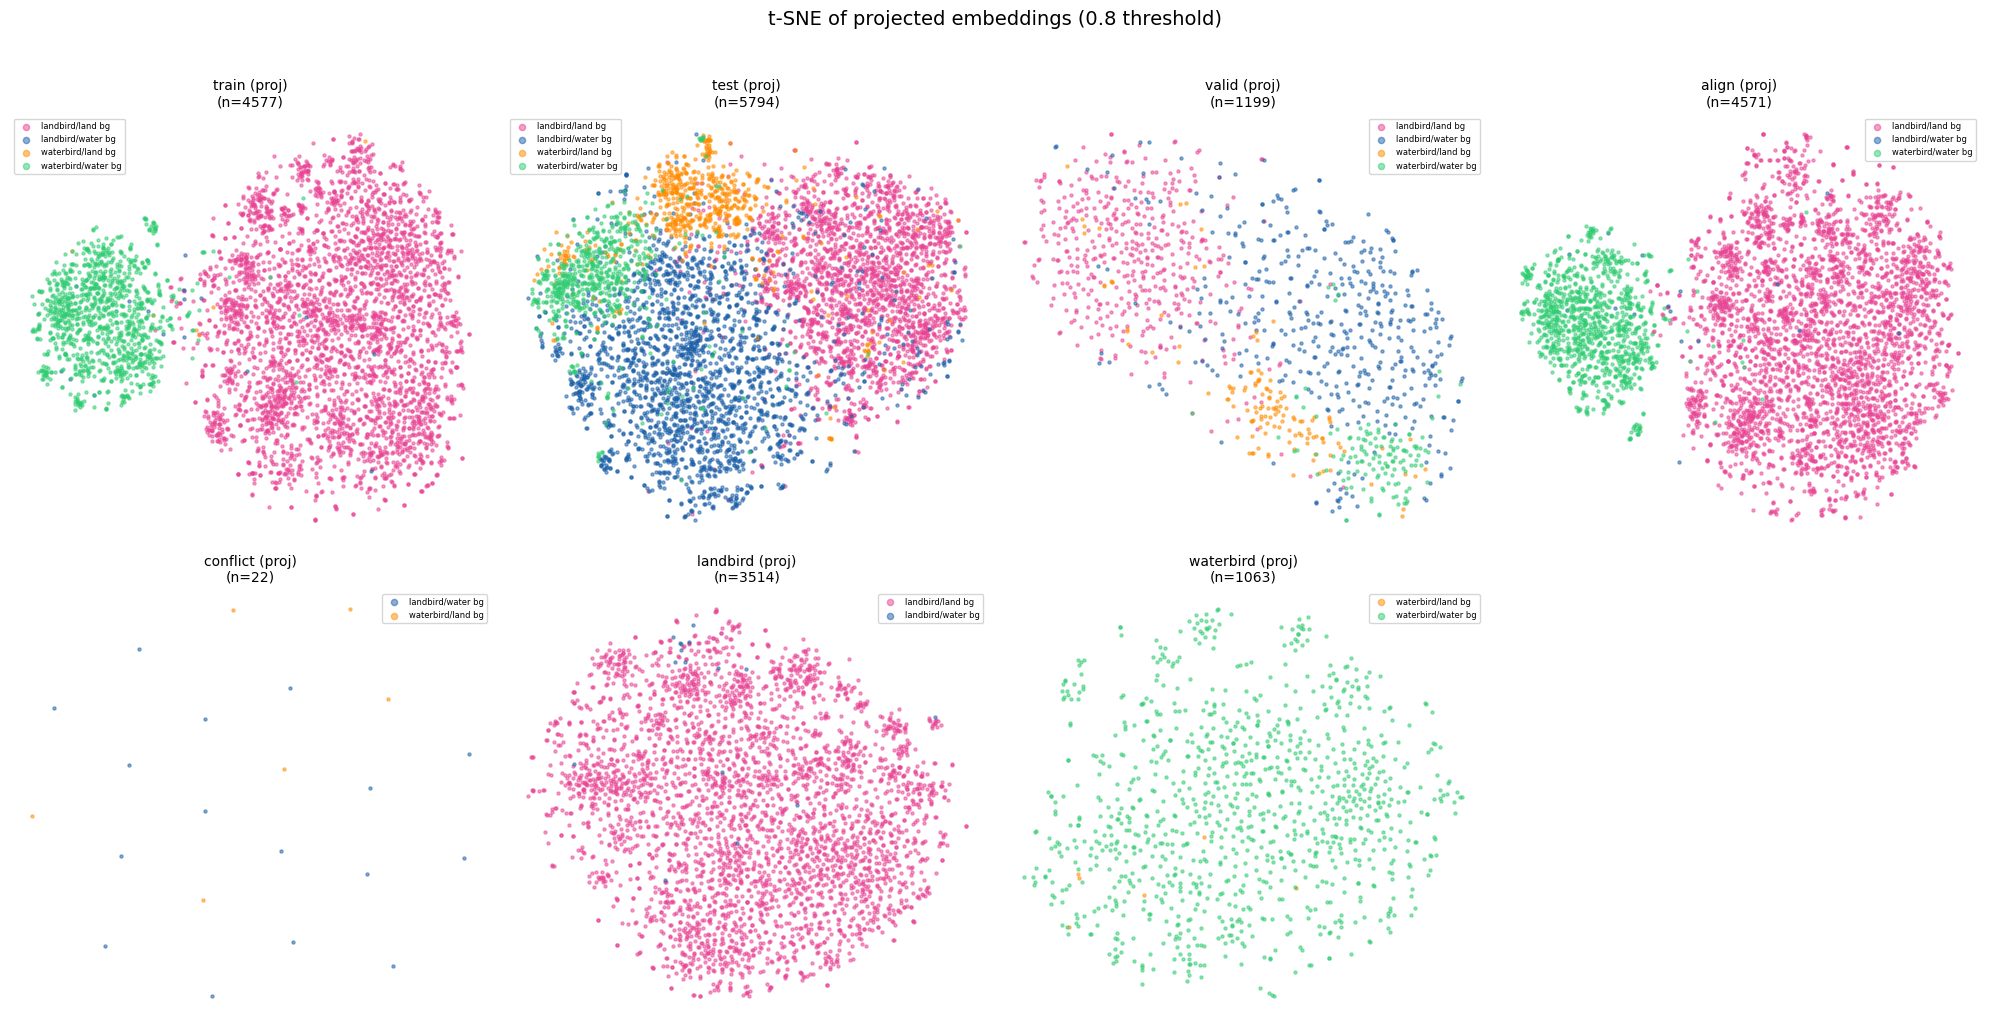

In [141]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("0.5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.8).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.8 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("0.5pct/push_pull/tsne/tsne_projected_all_splits(0.8).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [142]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # # Save original
    # plt.figure(figsize=(7, 6))
    # for g, gname in group_names.items():
    #     mask = group == g
    #     if mask.sum() == 0: continue
    #     plt.scatter(orig_2d[mask, 0], orig_2d[mask, 1],
    #                 c=colors[g], label=gname, s=5, alpha=0.6)
    # plt.title(f"{name} — original (n={n})", fontsize=13)
    # plt.legend(fontsize=9, markerscale=2)
    # plt.axis("off")
    # plt.tight_layout()
    # plt.savefig(f"0.5pct/tsne/tsne_{name}_original.png", dpi=150, bbox_inches="tight")
    # plt.close()
    # print(f"Saved tsne_{name}_original.png")

    # Save projected
    plt.figure(figsize=(7, 6))
    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        plt.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
                    c=colors[g], label=gname, s=5, alpha=0.6)
    plt.title(f"{name} — projected (n={n})", fontsize=13)
    plt.legend(fontsize=9, markerscale=2)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_projected(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_projected(0.8).png")

t-SNE projected train (4577 points)...


Saved tsne_train_projected(0.8).png
t-SNE projected test (5794 points)...
Saved tsne_test_projected(0.8).png
t-SNE projected valid (1199 points)...
Saved tsne_valid_projected(0.8).png
t-SNE projected align (4571 points)...
Saved tsne_align_projected(0.8).png
t-SNE projected conflict (22 points)...
Saved tsne_conflict_projected(0.8).png
t-SNE projected landbird (3514 points)...
Saved tsne_landbird_projected(0.8).png
t-SNE projected waterbird (1063 points)...
Saved tsne_waterbird_projected(0.8).png


In [143]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.8).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.8).png")

t-SNE original  train (4577 points)...
t-SNE projected train (4577 points)...
Saved tsne_train_orig_vs_proj(0.8).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.8).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.8).png
t-SNE original  align (4571 points)...
t-SNE projected align (4571 points)...
Saved tsne_align_orig_vs_proj(0.8).png
t-SNE original  conflict (22 points)...
t-SNE projected conflict (22 points)...
Saved tsne_conflict_orig_vs_proj(0.8).png
t-SNE original  landbird (3514 points)...
t-SNE projected landbird (3514 points)...
Saved tsne_landbird_orig_vs_proj(0.8).png
t-SNE original  waterbird (1063 points)...
t-SNE projected waterbird (1063 points)...
Saved tsne_waterbird_orig_vs_proj(0.8).png


## Similarity Threshold = 0.7

In [144]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.70
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3514, 768])
waterbird: torch.Size([1063, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3514, 1063])
mean=0.600  max=0.881  min=0.218

Pairs with sim > 0.7: 166922
sim range: 0.700 - 0.881
mean sim of selected pairs: 0.721
0.00 minutes


In [145]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.7).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.7): 166922



Total pairs: 333844
  push (landbird↔waterbird):                166922
  pull (landbird↔landbird + water↔water):   166922
Before training:
  push_sim(landbird↔waterbird):     0.723
  pull_sim(landbird↔landbird):      0.669
  pull_sim(waterbird↔waterbird):    0.646

Training...
  epoch   0  loss=0.0404  push_sim=0.160  pull_landbird=0.868  pull_waterbird=0.872  W_diff=0.00887
  epoch  10  loss=0.0002  push_sim=0.035  pull_landbird=0.896  pull_waterbird=0.892  W_diff=0.00683
  epoch  20  loss=0.0000  push_sim=0.022  pull_landbird=0.953  pull_waterbird=0.925  W_diff=0.00351
  epoch  30  loss=0.0000  push_sim=-0.057  pull_landbird=0.960  pull_waterbird=0.955  W_diff=0.00255
  epoch  40  loss=0.0000  push_sim=-0.015  pull_landbird=0.965  pull_waterbird=0.956  W_diff=0.00214
Done!
18.0 minutes


In [146]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.7: {(sim_before_flat>0.7).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.7: {(sim_after_flat>0.7).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.600  max=0.881  >0.7: 166922
  AFTER:  mean=-0.034  max=0.650  >0.7: 0

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.672  min=0.220
  AFTER:  mean=0.966  min=0.608

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.647  min=0.299
  AFTER:  mean=0.955  min=0.768
W_diff from identity: 0.00201


In [147]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj_push_pull(0.7).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj_push_pull(0.7).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj_push_pull(0.7).pt")
print("Saved!")

Saved!


In [148]:
train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj_push_pull(0.7).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj_push_pull(0.7).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj_push_pull(0.7).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}") 
print(f"valid_proj: {valid_proj.shape}")  

train_proj: torch.Size([4577, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 74.6%
  landbird/land bg: 99.4%
  landbird/water bg: 47.0%
  waterbird/land bg: 59.4%
  waterbird/water bg: 99.2%
  worst: 47.0%  best: 99.4%  gap: 52.4%

  DEBIASED (linear push)
Overall accuracy: 77.8%
  landbird/land bg: 99.6%
  landbird/water bg: 55.4%
  waterbird/land bg: 59.4%
  waterbird/water bg: 98.5%
  worst: 55.4%  best: 99.6%  gap: 44.2%


Running t-SNE for train (proj) (4577 points)...
Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4571 points)...
Running t-SNE for conflict (proj) (22 points)...
Running t-SNE for landbird (proj) (3514 points)...
Running t-SNE for waterbird (proj) (1063 points)...
Saved!


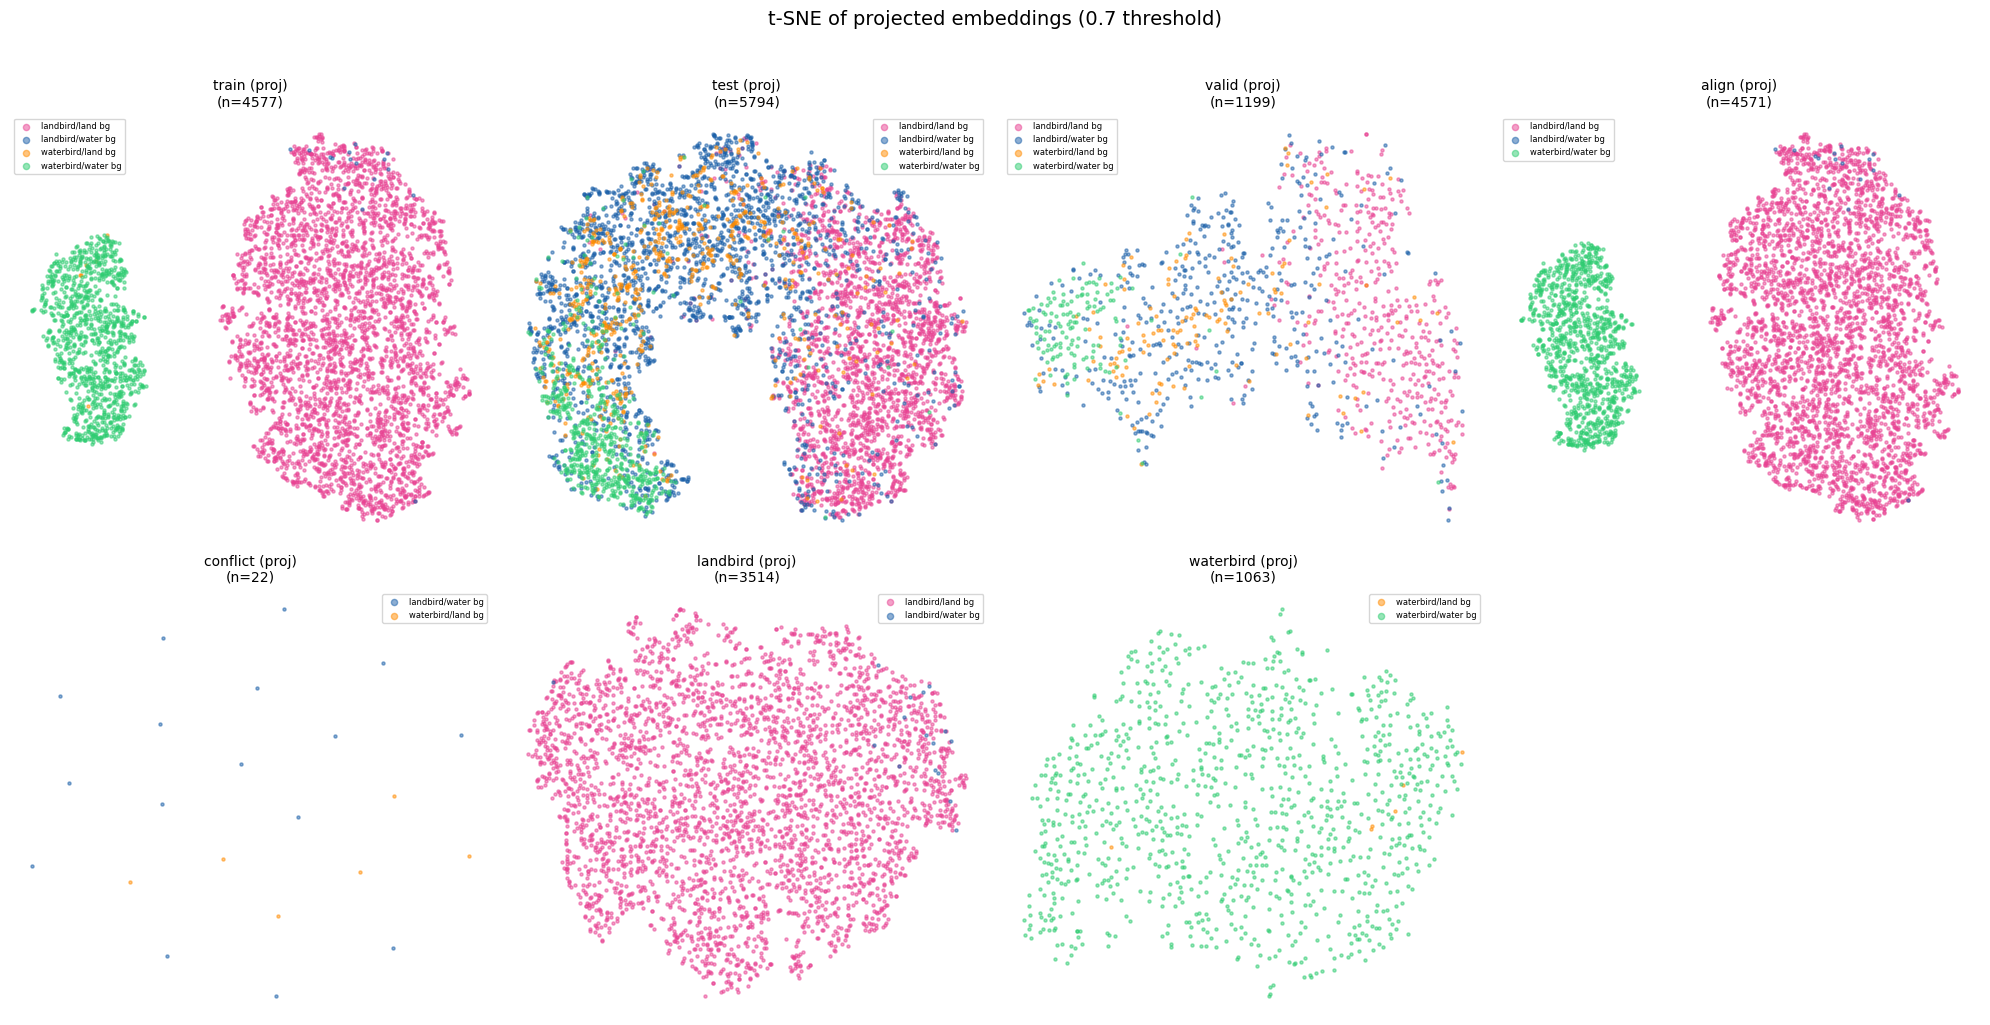

In [177]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("0.5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.7).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.7 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("0.5pct/push_pull/tsne/tsne_projected_all_splits(0.7).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [178]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.7).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.7).png")

t-SNE original  train (4577 points)...
t-SNE projected train (4577 points)...
Saved tsne_train_orig_vs_proj(0.7).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.7).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.7).png
t-SNE original  align (4571 points)...
t-SNE projected align (4571 points)...
Saved tsne_align_orig_vs_proj(0.7).png
t-SNE original  conflict (22 points)...
t-SNE projected conflict (22 points)...
Saved tsne_conflict_orig_vs_proj(0.7).png
t-SNE original  landbird (3514 points)...
t-SNE projected landbird (3514 points)...
Saved tsne_landbird_orig_vs_proj(0.7).png
t-SNE original  waterbird (1063 points)...
t-SNE projected waterbird (1063 points)...
Saved tsne_waterbird_orig_vs_proj(0.7).png


## Similarity Threshold = 0.9

In [ ]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.90
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3514, 768])
waterbird: torch.Size([1063, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3514, 1063])
mean=0.600  max=0.881  min=0.218

Pairs with sim > 0.9: 0


RuntimeError: min(): Expected reduction dim to be specified for input.numel() == 0. Specify the reduction dim with the 'dim' argument.

## Similarity Threshold = 0.65

In [165]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.65
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3514, 768])
waterbird: torch.Size([1063, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3514, 1063])
mean=0.600  max=0.881  min=0.218

Pairs with sim > 0.65: 815710
sim range: 0.650 - 0.881
mean sim of selected pairs: 0.681
0.00 minutes


In [166]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.65).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.65): 815710

Total pairs: 1631420
  push (landbird↔waterbird):                815710
  pull (landbird↔landbird + water↔water):   815710
Before training:
  push_sim(landbird↔waterbird):     0.676
  pull_sim(landbird↔landbird):      0.669
  pull_sim(waterbird↔waterbird):    0.646

Training...
  epoch   0  loss=0.0102  push_sim=0.095  pull_landbird=0.894  pull_waterbird=0.883  W_diff=0.00958
  epoch  10  loss=0.0000  push_sim=-0.019  pull_landbird=0.962  pull_waterbird=0.946  W_diff=0.00245
  epoch  20  loss=0.0000  push_sim=-0.070  pull_landbird=0.960  pull_waterbird=0.950  W_diff=0.00222
  epoch  30  loss=0.0000  push_sim=-0.097  pull_landbird=0.965  pull_waterbird=0.952  W_diff=0.00190
  epoch  40  loss=0.0000  push_sim=-0.095  pull_landbird=0.972  pull_waterbird=0.964  W_diff=0.00159
Done!
88.9 minutes


In [167]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.65: {(sim_before_flat>0.65).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.65: {(sim_after_flat>0.65).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.600  max=0.881  >0.65: 815710
  AFTER:  mean=-0.060  max=0.596  >0.65: 0

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.672  min=0.220
  AFTER:  mean=0.979  min=0.735

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.647  min=0.299
  AFTER:  mean=0.971  min=0.794
W_diff from identity: 0.00141


In [168]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj_push_pull(0.65).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj_push_pull(0.65).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj_push_pull(0.65).pt")
print("Saved!")

Saved!


In [169]:
train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj_push_pull(0.65).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj_push_pull(0.65).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj_push_pull(0.65).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}") 
print(f"valid_proj: {valid_proj.shape}")  

train_proj: torch.Size([4577, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 74.6%
  landbird/land bg: 99.4%
  landbird/water bg: 47.0%
  waterbird/land bg: 59.4%
  waterbird/water bg: 99.2%
  worst: 47.0%  best: 99.4%  gap: 52.4%

  DEBIASED (linear push)
Overall accuracy: 78.6%
  landbird/land bg: 99.8%
  landbird/water bg: 56.4%
  waterbird/land bg: 61.7%
  waterbird/water bg: 98.5%
  worst: 56.4%  best: 99.8%  gap: 43.3%


Running t-SNE for train (proj) (4577 points)...
Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4571 points)...
Running t-SNE for conflict (proj) (22 points)...
Running t-SNE for landbird (proj) (3514 points)...
Running t-SNE for waterbird (proj) (1063 points)...
Saved!


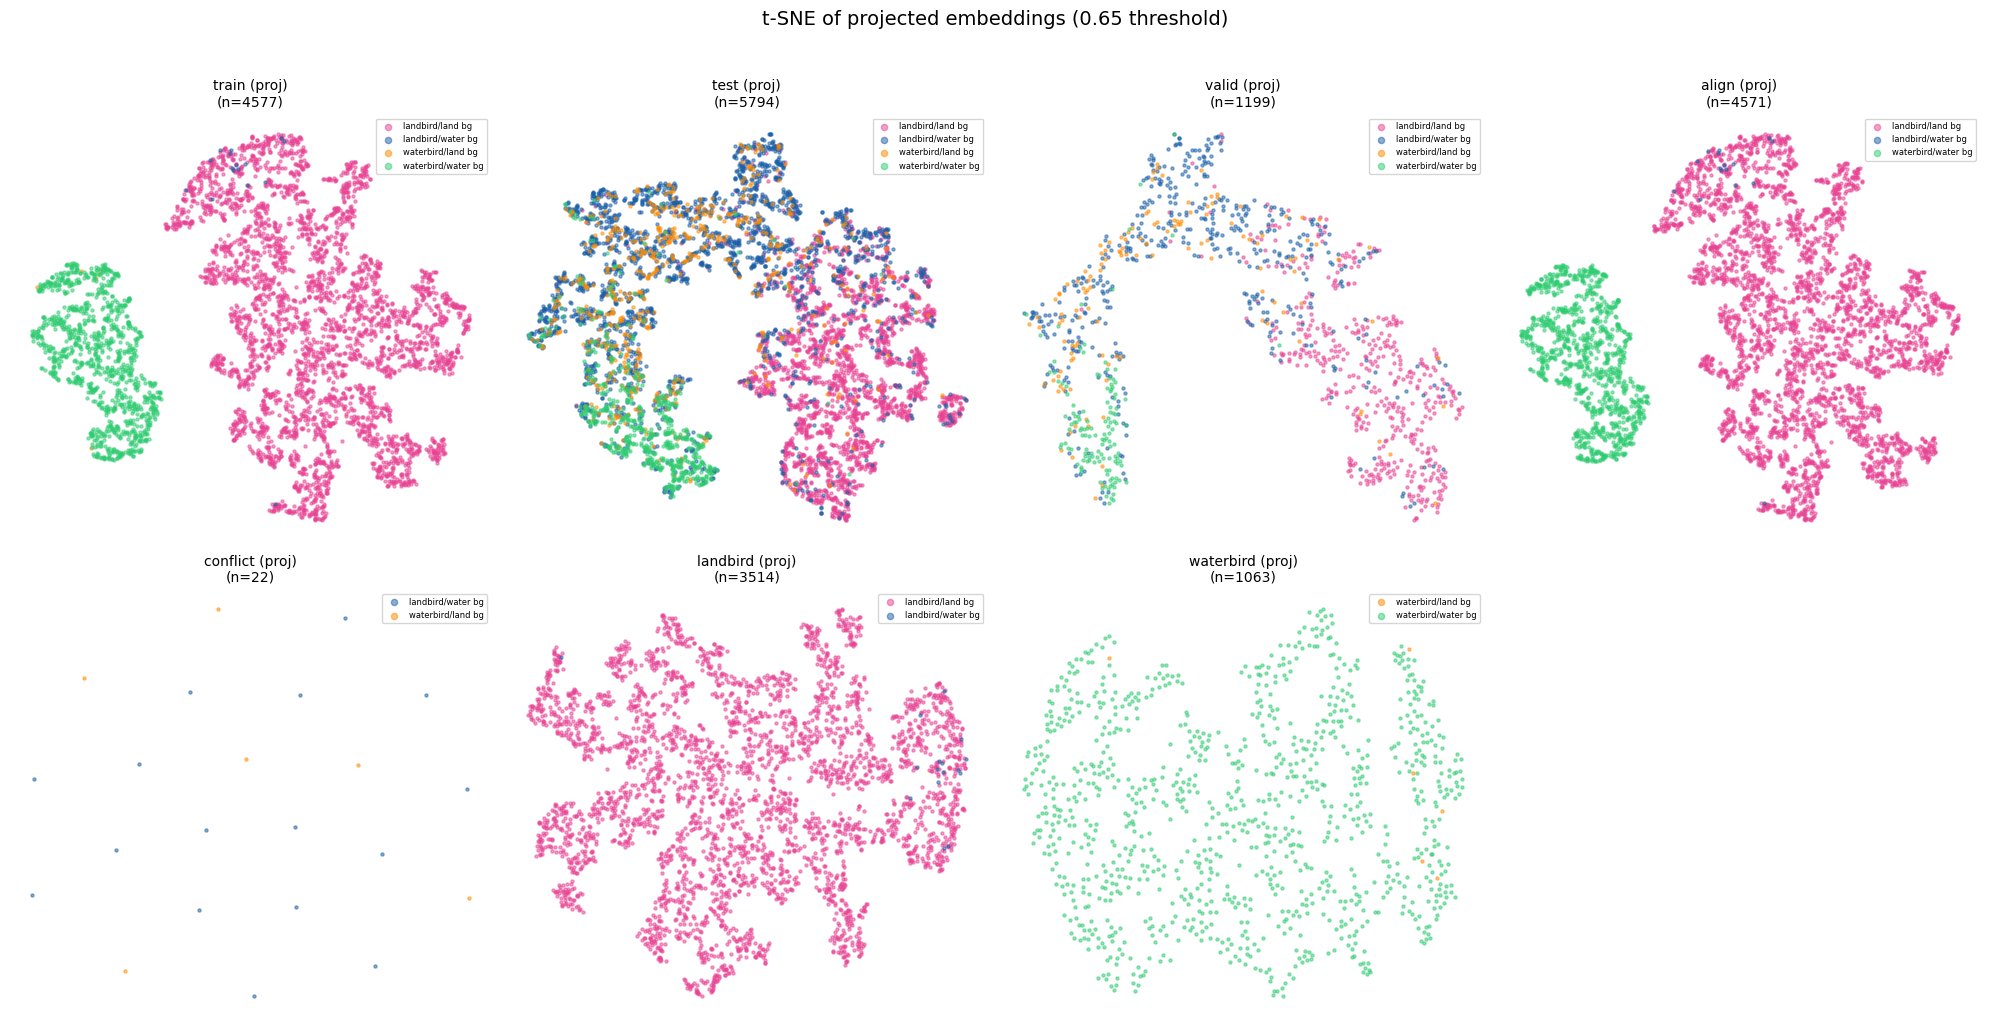

In [179]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("0.5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.65).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.65 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("0.5pct/push_pull/tsne/tsne_projected_all_splits(0.65).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [180]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.65).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.65).png")

t-SNE original  train (4577 points)...
t-SNE projected train (4577 points)...
Saved tsne_train_orig_vs_proj(0.65).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.65).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.65).png
t-SNE original  align (4571 points)...
t-SNE projected align (4571 points)...
Saved tsne_align_orig_vs_proj(0.65).png
t-SNE original  conflict (22 points)...
t-SNE projected conflict (22 points)...
Saved tsne_conflict_orig_vs_proj(0.65).png
t-SNE original  landbird (3514 points)...
t-SNE projected landbird (3514 points)...
Saved tsne_landbird_orig_vs_proj(0.65).png
t-SNE original  waterbird (1063 points)...
t-SNE projected waterbird (1063 points)...
Saved tsne_waterbird_orig_vs_proj(0.65).png


## Similarity Threshold = 0.60

In [171]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.60
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3514, 768])
waterbird: torch.Size([1063, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3514, 1063])
mean=0.600  max=0.881  min=0.218

Pairs with sim > 0.6: 1967556
sim range: 0.600 - 0.881
mean sim of selected pairs: 0.648
0.00 minutes


In [172]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.60).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.6): 1967556

Total pairs: 3935112
  push (landbird↔waterbird):                1967556
  pull (landbird↔landbird + water↔water):   1967556
Before training:
  push_sim(landbird↔waterbird):     0.634
  pull_sim(landbird↔landbird):      0.669
  pull_sim(waterbird↔waterbird):    0.646

Training...
  epoch   0  loss=0.0042  push_sim=-0.026  pull_landbird=0.909  pull_waterbird=0.895  W_diff=0.00626
  epoch  10  loss=0.0000  push_sim=-0.092  pull_landbird=0.964  pull_waterbird=0.947  W_diff=0.00228
  epoch  20  loss=0.0000  push_sim=-0.089  pull_landbird=0.960  pull_waterbird=0.950  W_diff=0.00207
  epoch  30  loss=0.0000  push_sim=-0.073  pull_landbird=0.964  pull_waterbird=0.948  W_diff=0.00184
  epoch  40  loss=0.0000  push_sim=-0.117  pull_landbird=0.974  pull_waterbird=0.961  W_diff=0.00154
Done!
212.5 minutes


In [173]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.60: {(sim_before_flat>0.60).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.60: {(sim_after_flat>0.60).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.600  max=0.881  >0.60: 1967556
  AFTER:  mean=-0.070  max=0.585  >0.60: 0

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.672  min=0.220
  AFTER:  mean=0.985  min=0.811

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.647  min=0.299
  AFTER:  mean=0.979  min=0.847
W_diff from identity: 0.00135


In [174]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj_push_pull(0.6).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj_push_pull(0.6).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj_push_pull(0.6).pt")
print("Saved!")

Saved!


In [175]:
train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj_push_pull(0.6).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj_push_pull(0.6).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj_push_pull(0.6).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}") 
print(f"valid_proj: {valid_proj.shape}")  

train_proj: torch.Size([4577, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


In [176]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 74.6%
  landbird/land bg: 99.4%
  landbird/water bg: 47.0%
  waterbird/land bg: 59.4%
  waterbird/water bg: 99.2%
  worst: 47.0%  best: 99.4%  gap: 52.4%

  DEBIASED (linear push)
Overall accuracy: 78.2%
  landbird/land bg: 99.6%
  landbird/water bg: 56.0%
  waterbird/land bg: 60.9%
  waterbird/water bg: 98.5%
  worst: 56.0%  best: 99.6%  gap: 43.6%


Running t-SNE for train (proj) (4577 points)...
Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4571 points)...
Running t-SNE for conflict (proj) (22 points)...
Running t-SNE for landbird (proj) (3514 points)...
Running t-SNE for waterbird (proj) (1063 points)...
Saved!


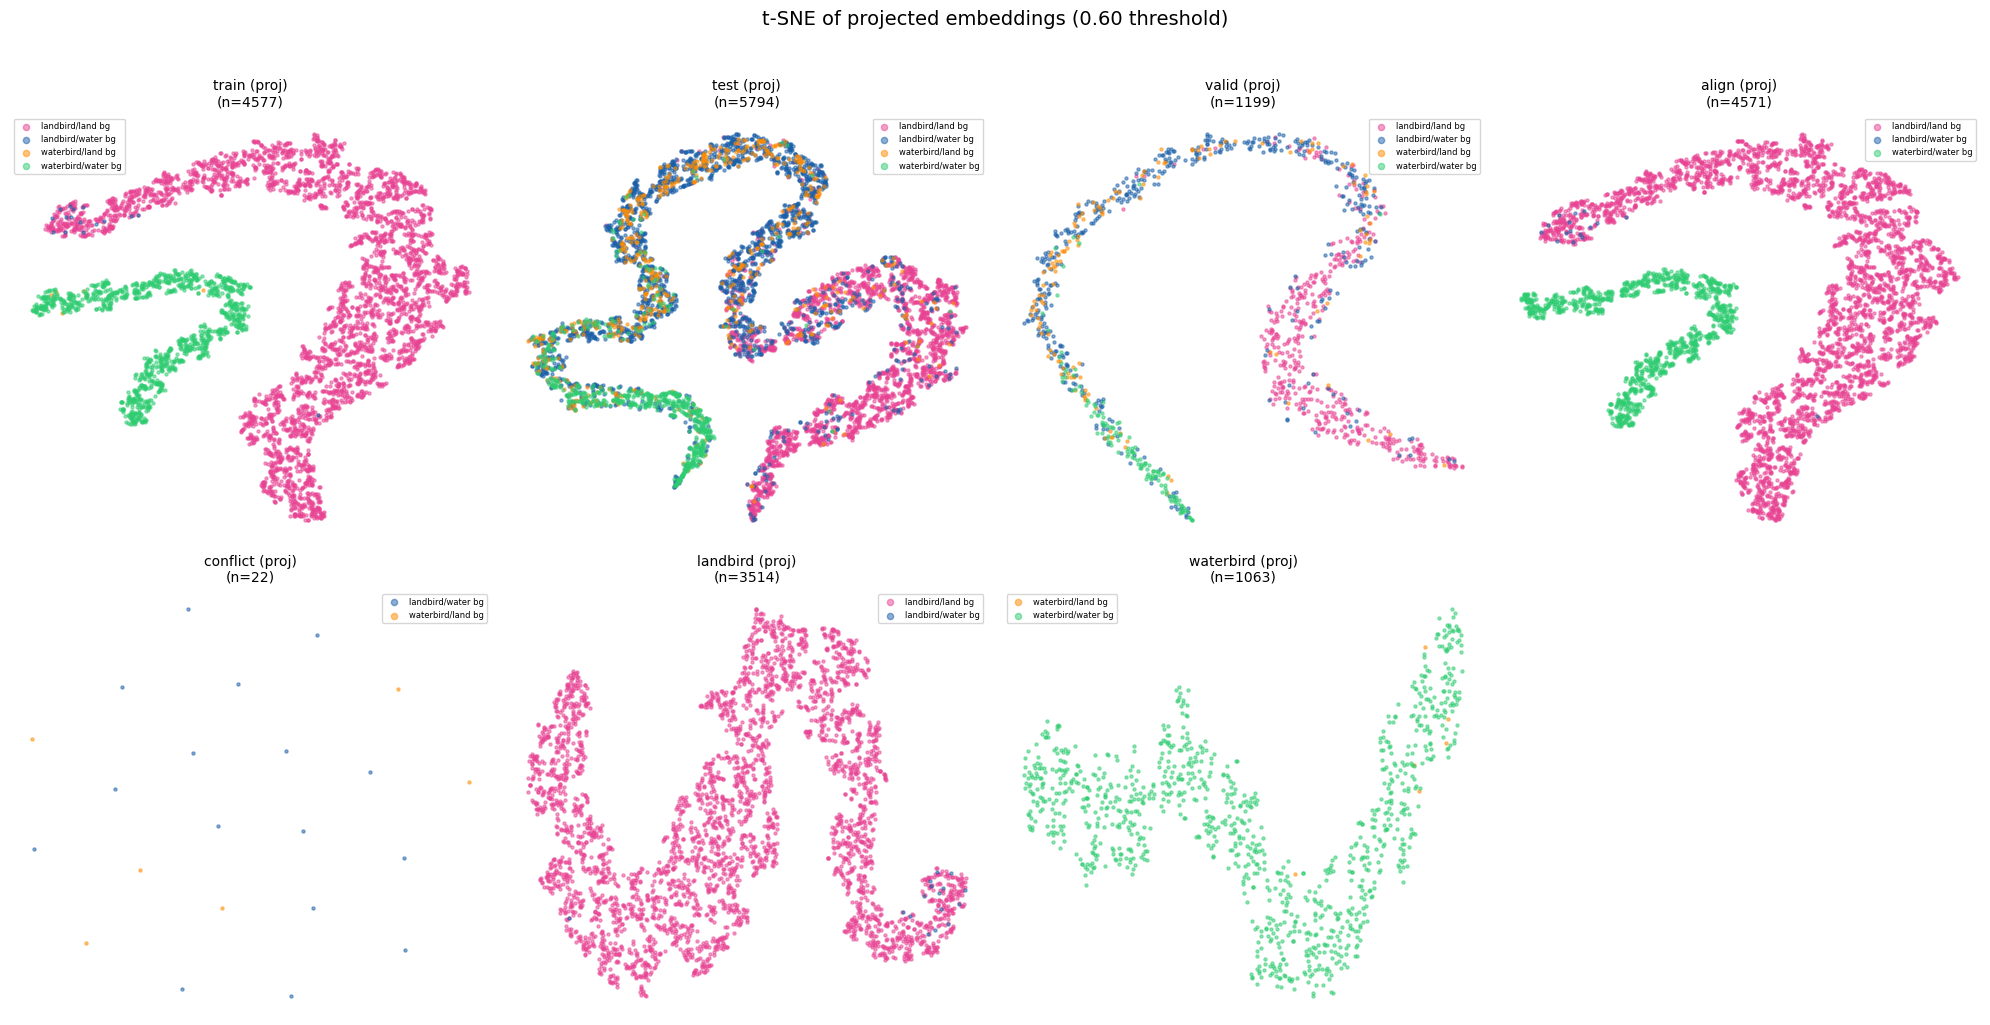

In [181]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("0.5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.60).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.60 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("0.5pct/push_pull/tsne/tsne_projected_all_splits(0.60).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [182]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.60).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.60).png")

t-SNE original  train (4577 points)...
t-SNE projected train (4577 points)...
Saved tsne_train_orig_vs_proj(0.60).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.60).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.60).png
t-SNE original  align (4571 points)...
t-SNE projected align (4571 points)...
Saved tsne_align_orig_vs_proj(0.60).png
t-SNE original  conflict (22 points)...
t-SNE projected conflict (22 points)...
Saved tsne_conflict_orig_vs_proj(0.60).png
t-SNE original  landbird (3514 points)...
t-SNE projected landbird (3514 points)...
Saved tsne_landbird_orig_vs_proj(0.60).png
t-SNE original  waterbird (1063 points)...
t-SNE projected waterbird (1063 points)...
Saved tsne_waterbird_orig_vs_proj(0.60).png


## Similarity Threshold = 0.75

In [150]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.75
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3514, 768])
waterbird: torch.Size([1063, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3514, 1063])
mean=0.600  max=0.881  min=0.218

Pairs with sim > 0.75: 14415
sim range: 0.750 - 0.881
mean sim of selected pairs: 0.766
0.00 minutes


In [151]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.75).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.75): 14415



Total pairs: 28829
  push (landbird↔waterbird):                14415
  pull (landbird↔landbird + water↔water):   14414
Before training:
  push_sim(landbird↔waterbird):     0.767
  pull_sim(landbird↔landbird):      0.669
  pull_sim(waterbird↔waterbird):    0.646

Training...
  epoch   0  loss=0.2474  push_sim=0.569  pull_landbird=0.727  pull_waterbird=0.749  W_diff=0.00312
  epoch  10  loss=0.0124  push_sim=0.210  pull_landbird=0.861  pull_waterbird=0.867  W_diff=0.00909
  epoch  20  loss=0.0058  push_sim=0.185  pull_landbird=0.870  pull_waterbird=0.874  W_diff=0.00997
  epoch  30  loss=0.0037  push_sim=0.208  pull_landbird=0.874  pull_waterbird=0.876  W_diff=0.01011
  epoch  40  loss=0.0031  push_sim=0.205  pull_landbird=0.873  pull_waterbird=0.875  W_diff=0.01008
Done!
1.6 minutes


In [152]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.75: {(sim_before_flat>0.75).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.75: {(sim_after_flat>0.75).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.600  max=0.881  >0.75: 14415
  AFTER:  mean=0.163  max=0.890  >0.75: 5243

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.672  min=0.220
  AFTER:  mean=0.873  min=0.093

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.647  min=0.299
  AFTER:  mean=0.874  min=0.443
W_diff from identity: 0.01008


In [153]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj_push_pull(0.75).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj_push_pull(0.75).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj_push_pull(0.75).pt")
print("Saved!")

Saved!


In [154]:
train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj_push_pull(0.75).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj_push_pull(0.75).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj_push_pull(0.75).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}") 
print(f"valid_proj: {valid_proj.shape}")  

train_proj: torch.Size([4577, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 74.6%
  landbird/land bg: 99.4%
  landbird/water bg: 47.0%
  waterbird/land bg: 59.4%
  waterbird/water bg: 99.2%
  worst: 47.0%  best: 99.4%  gap: 52.4%

  DEBIASED (linear push)
Overall accuracy: 76.1%
  landbird/land bg: 99.4%
  landbird/water bg: 51.3%
  waterbird/land bg: 59.4%
  waterbird/water bg: 98.5%
  worst: 51.3%  best: 99.4%  gap: 48.1%


Running t-SNE for train (proj) (4577 points)...
Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4571 points)...
Running t-SNE for conflict (proj) (22 points)...
Running t-SNE for landbird (proj) (3514 points)...
Running t-SNE for waterbird (proj) (1063 points)...
Saved!


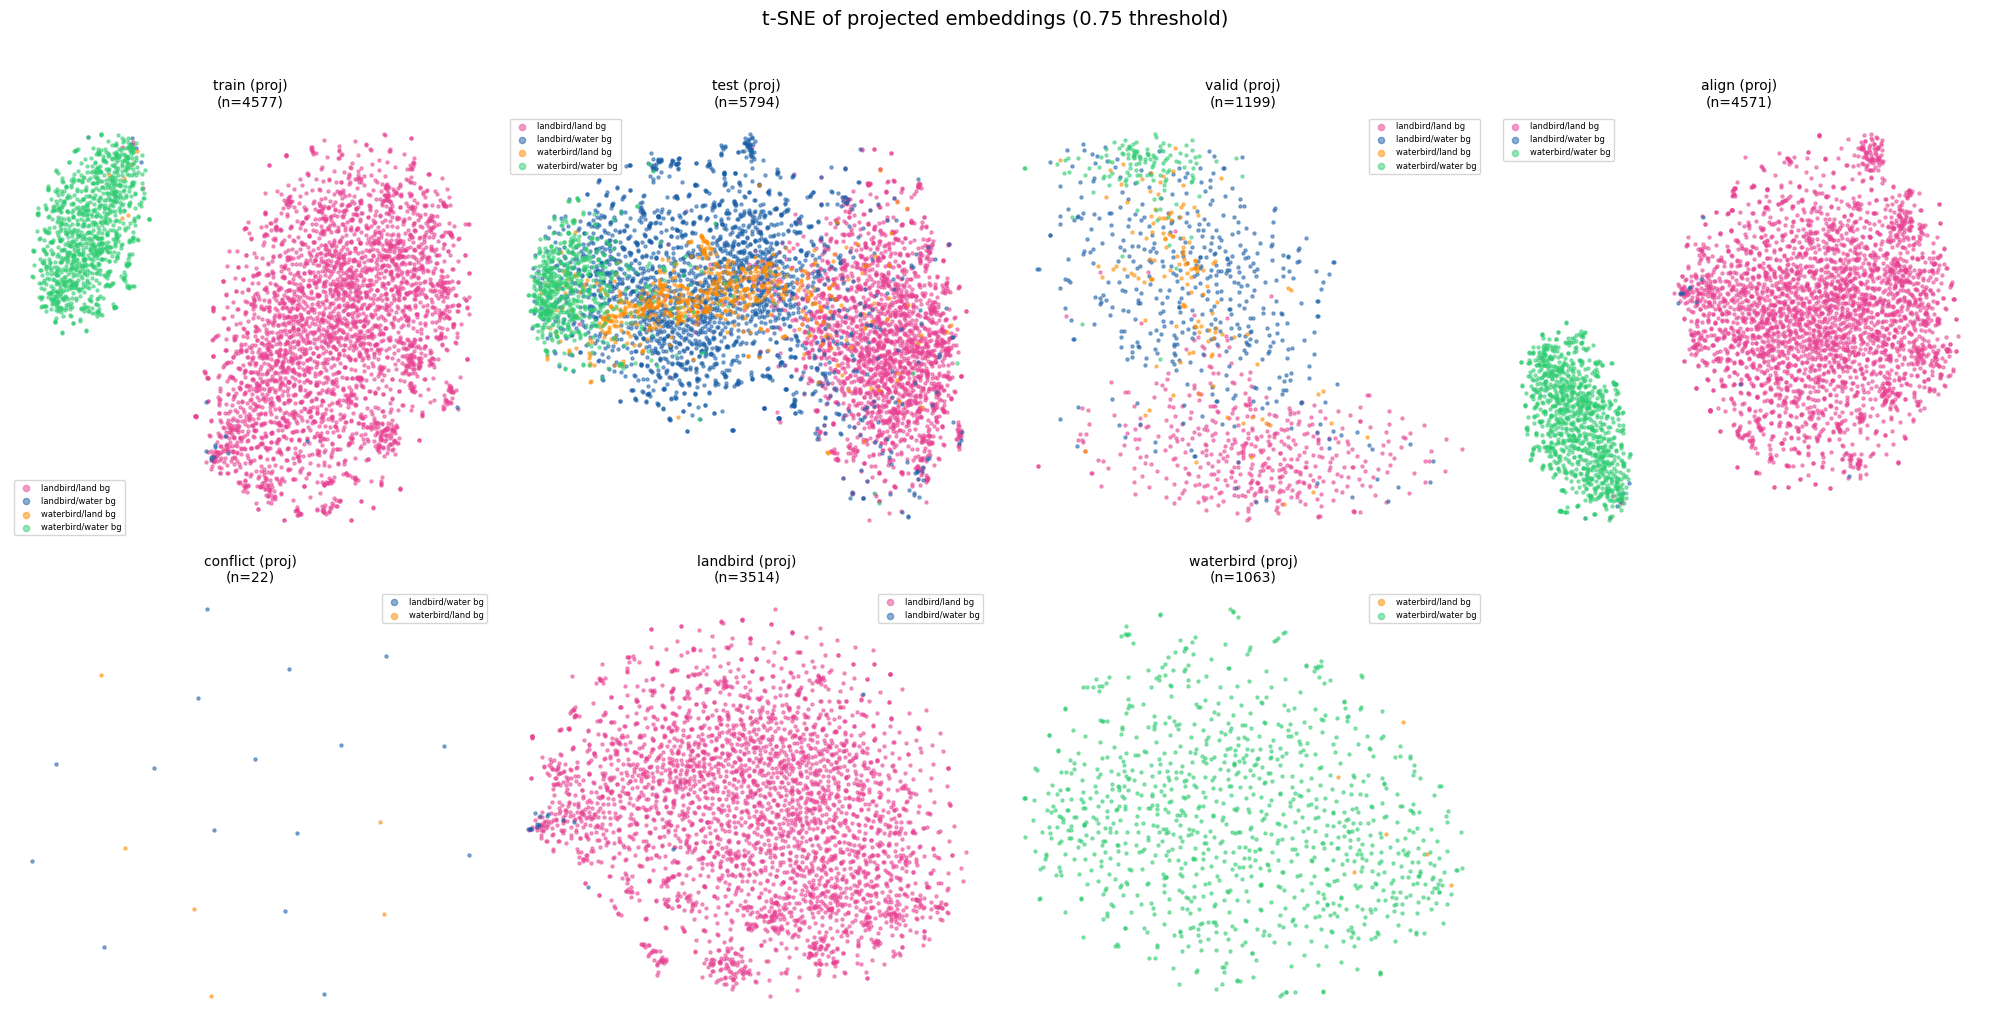

In [183]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("0.5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.75).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.75 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("0.5pct/push_pull/tsne/tsne_projected_all_splits(0.75).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [184]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.75).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.75).png")

t-SNE original  train (4577 points)...
t-SNE projected train (4577 points)...
Saved tsne_train_orig_vs_proj(0.75).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.75).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.75).png
t-SNE original  align (4571 points)...
t-SNE projected align (4571 points)...
Saved tsne_align_orig_vs_proj(0.75).png
t-SNE original  conflict (22 points)...
t-SNE projected conflict (22 points)...
Saved tsne_conflict_orig_vs_proj(0.75).png
t-SNE original  landbird (3514 points)...
t-SNE projected landbird (3514 points)...
Saved tsne_landbird_orig_vs_proj(0.75).png
t-SNE original  waterbird (1063 points)...
t-SNE projected waterbird (1063 points)...
Saved tsne_waterbird_orig_vs_proj(0.75).png


## Similarity Threshold = 0.85

In [156]:
import time

# Load label-based embeddings
landbird_embs  = embs_0   # all landbird  (label=0)
waterbird_embs = embs_1   # all waterbird (label=1)

print(f"landbird:  {landbird_embs.shape}")
print(f"waterbird: {waterbird_embs.shape}")

# Normalize
landbird_norm  = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
waterbird_norm = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

start = time.time()
# Similarity matrix landbird↔waterbird
print("Computing similarity matrix...")
sim_matrix = landbird_norm @ waterbird_norm.T
print(f"sim_matrix shape: {sim_matrix.shape}")
print(f"mean={sim_matrix.mean():.3f}  max={sim_matrix.max():.3f}  min={sim_matrix.min():.3f}")

# Find pairs with similarity > threshold k
k_threshold = 0.85
high_sim_mask = sim_matrix > k_threshold
n_pairs = high_sim_mask.sum().item()
print(f"\nPairs with sim > {k_threshold}: {n_pairs}")

# Get indices of high similarity pairs
landbird_idx, waterbird_idx = torch.where(high_sim_mask)
sim_vals = sim_matrix[landbird_idx, waterbird_idx]

print(f"sim range: {sim_vals.min():.3f} - {sim_vals.max():.3f}")
print(f"mean sim of selected pairs: {sim_vals.mean():.3f}")

end = time.time()
print(f"{(end-start)/60:.2f} minutes")

landbird:  torch.Size([3514, 768])
waterbird: torch.Size([1063, 768])
Computing similarity matrix...
sim_matrix shape: torch.Size([3514, 1063])
mean=0.600  max=0.881  min=0.218

Pairs with sim > 0.85: 7
sim range: 0.852 - 0.881
mean sim of selected pairs: 0.861
0.00 minutes


In [157]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
import os
os.makedirs("0.5pct/push_pull/Projection_heads", exist_ok=True)

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

def push_pull_loss(e1, e2, sim_weight, label, margin_neg=0.5, margin_pos=0.8):
    sim = F.cosine_similarity(e1, e2)

    neg_mask = (label == 0)
    pos_mask = (label == 1)

    push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        push = (sim_weight[neg_mask] * torch.clamp(sim[neg_mask] - margin_neg, min=0)).mean()

    pull = torch.tensor(0.0, device=e1.device)
    if pos_mask.sum() > 0:
        pull = torch.clamp(margin_pos - sim[pos_mask], min=0).mean()

    over_push = torch.tensor(0.0, device=e1.device)
    if neg_mask.sum() > 0:
        over_push = torch.clamp(-sim[neg_mask] - margin_neg, min=0).mean()

    return push + pull + 0.5 * over_push

# --- Negative pairs (push) ---
print(f"Push pairs (landbird↔waterbird, sim>{k_threshold}): {n_pairs}")
neg_e1      = landbird_embs[landbird_idx]
neg_e2      = waterbird_embs[waterbird_idx]
neg_weights = sim_vals
neg_labels  = torch.zeros(n_pairs)

# --- Positive pairs (pull) ---
n_pos_each = n_pairs // 2

# landbird↔landbird
lb_idx1     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
lb_idx2     = torch.randint(0, len(landbird_embs),  (n_pos_each,))
land_pos_e1 = landbird_embs[lb_idx1]
land_pos_e2 = landbird_embs[lb_idx2]

# waterbird↔waterbird
wb_idx1      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
wb_idx2      = torch.randint(0, len(waterbird_embs), (n_pos_each,))
water_pos_e1 = waterbird_embs[wb_idx1]
water_pos_e2 = waterbird_embs[wb_idx2]

pos_e1      = torch.cat([land_pos_e1,  water_pos_e1])
pos_e2      = torch.cat([land_pos_e2,  water_pos_e2])
pos_weights = torch.ones(len(pos_e1))
pos_labels  = torch.ones(len(pos_e1))

# --- Combine ---
all_e1      = torch.cat([neg_e1,      pos_e1])
all_e2      = torch.cat([neg_e2,      pos_e2])
all_weights = torch.cat([neg_weights, pos_weights])
all_labels  = torch.cat([neg_labels,  pos_labels])

print(f"\nTotal pairs: {len(all_e1)}")
print(f"  push (landbird↔waterbird):                {(all_labels==0).sum()}")
print(f"  pull (landbird↔landbird + water↔water):   {(all_labels==1).sum()}")

# --- Train ---
device     = "cuda"
model_head = LinearDebias().to(device)
optimizer  = optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dataset    = TensorDataset(all_e1, all_e2, all_weights, all_labels)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

n_wb = min(500, len(waterbird_embs) // 2)  # safe size for both slices

# --- Check before training ---
model_head.eval()
with torch.no_grad():
    p1 = model_head(neg_e1[:1000].to(device))
    p2 = model_head(neg_e2[:1000].to(device))
    p3 = model_head(landbird_embs[:1000].to(device))
    p4 = model_head(landbird_embs[1000:2000].to(device))
    p5 = model_head(waterbird_embs[:n_wb].to(device))
    p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
print(f"Before training:")
print(f"  push_sim(landbird↔waterbird):     {F.cosine_similarity(p1,p2).mean():.3f}")
print(f"  pull_sim(landbird↔landbird):      {F.cosine_similarity(p3,p4).mean():.3f}")
print(f"  pull_sim(waterbird↔waterbird):    {F.cosine_similarity(p5,p6).mean():.3f}")
start = time.time()
print("\nTraining...")
for epoch in range(50):
    model_head.train()
    total_loss = 0
    for b_e1, b_e2, b_sw, b_lbl in dataloader:
        b_e1  = b_e1.to(device)
        b_e2  = b_e2.to(device)
        b_sw  = b_sw.to(device)
        b_lbl = b_lbl.to(device)

        proj1 = model_head(b_e1)
        proj2 = model_head(b_e2)

        loss = push_pull_loss(proj1, proj2, b_sw, b_lbl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_head.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    if epoch % 10 == 0:
        model_head.eval()
        with torch.no_grad():
            p1 = model_head(neg_e1[:1000].to(device))
            p2 = model_head(neg_e2[:1000].to(device))
            p3 = model_head(landbird_embs[:1000].to(device))
            p4 = model_head(landbird_embs[1000:2000].to(device))
            p5 = model_head(waterbird_embs[:n_wb].to(device))
            p6 = model_head(waterbird_embs[n_wb:n_wb*2].to(device))
            push_sim       = F.cosine_similarity(p1, p2).mean().item()
            pull_landbird  = F.cosine_similarity(p3, p4).mean().item()
            pull_waterbird = F.cosine_similarity(p5, p6).mean().item()
            w_diff         = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
        print(f"  epoch {epoch:3d}  loss={total_loss/len(dataloader):.4f}  "
              f"push_sim={push_sim:.3f}  "
              f"pull_landbird={pull_landbird:.3f}  pull_waterbird={pull_waterbird:.3f}  "
              f"W_diff={w_diff:.5f}")

print("Done!")
torch.save(model_head.state_dict(), "0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.85).pt")
end = time.time()
print(f"{(end-start)/60:.1f} minutes")

Push pairs (landbird↔waterbird, sim>0.85): 7

Total pairs: 13
  push (landbird↔waterbird):                7
  pull (landbird↔landbird + water↔water):   6
Before training:
  push_sim(landbird↔waterbird):     0.861
  pull_sim(landbird↔landbird):      0.669
  pull_sim(waterbird↔waterbird):    0.646

Training...
  epoch   0  loss=0.4391  push_sim=0.860  pull_landbird=0.674  pull_waterbird=0.651  W_diff=0.00010
  epoch  10  loss=0.3040  push_sim=0.844  pull_landbird=0.709  pull_waterbird=0.687  W_diff=0.00098
  epoch  20  loss=0.2586  push_sim=0.794  pull_landbird=0.698  pull_waterbird=0.679  W_diff=0.00135
  epoch  30  loss=0.2118  push_sim=0.741  pull_landbird=0.676  pull_waterbird=0.659  W_diff=0.00151
  epoch  40  loss=0.1857  push_sim=0.714  pull_landbird=0.664  pull_waterbird=0.649  W_diff=0.00158
Done!
0.0 minutes


In [158]:
model_head.eval()
with torch.no_grad():
    landbird_proj  = model_head(landbird_embs.to(device)).cpu()
    waterbird_proj = model_head(waterbird_embs.to(device)).cpu()

    landbird_proj_norm  = landbird_proj  / landbird_proj.norm(dim=-1, keepdim=True)
    waterbird_proj_norm = waterbird_proj / waterbird_proj.norm(dim=-1, keepdim=True)
    landbird_norm       = landbird_embs  / landbird_embs.norm(dim=-1, keepdim=True)
    waterbird_norm      = waterbird_embs / waterbird_embs.norm(dim=-1, keepdim=True)

    # Push: landbird↔waterbird similarity
    sim_after  = landbird_proj_norm @ waterbird_proj_norm.T
    sim_before = landbird_norm      @ waterbird_norm.T

    # Pull: within same class
    sim_ll_before = landbird_norm       @ landbird_norm.T
    sim_ll_after  = landbird_proj_norm  @ landbird_proj_norm.T
    sim_ww_before = waterbird_norm      @ waterbird_norm.T
    sim_ww_after  = waterbird_proj_norm @ waterbird_proj_norm.T

    mask_l = ~torch.eye(len(landbird_embs),  dtype=bool)
    mask_w = ~torch.eye(len(waterbird_embs), dtype=bool)

sim_after_flat  = sim_after.flatten()
sim_before_flat = sim_before.flatten()

print("=" * 55)
print("PUSH effect (landbird↔waterbird) — want lower:")
print(f"  BEFORE: mean={sim_before_flat.mean():.3f}  "
      f"max={sim_before_flat.max():.3f}  "
      f">0.85: {(sim_before_flat>0.85).sum()}")
print(f"  AFTER:  mean={sim_after_flat.mean():.3f}  "
      f"max={sim_after_flat.max():.3f}  "
      f">0.85: {(sim_after_flat>0.85).sum()}")

print("\nPULL effect (landbird↔landbird) — want higher:")
print(f"  BEFORE: mean={sim_ll_before[mask_l].mean():.3f}  "
      f"min={sim_ll_before[mask_l].min():.3f}")
print(f"  AFTER:  mean={sim_ll_after[mask_l].mean():.3f}  "
      f"min={sim_ll_after[mask_l].min():.3f}")

print("\nPULL effect (waterbird↔waterbird) — want higher:")
print(f"  BEFORE: mean={sim_ww_before[mask_w].mean():.3f}  "
      f"min={sim_ww_before[mask_w].min():.3f}")
print(f"  AFTER:  mean={sim_ww_after[mask_w].mean():.3f}  "
      f"min={sim_ww_after[mask_w].min():.3f}")

print("=" * 55)
w_diff = (model_head.W - torch.eye(768).to(device)).abs().mean().item()
print(f"W_diff from identity: {w_diff:.5f}")

PUSH effect (landbird↔waterbird) — want lower:
  BEFORE: mean=0.600  max=0.881  >0.85: 7
  AFTER:  mean=0.590  max=0.850  >0.85: 0

PULL effect (landbird↔landbird) — want higher:
  BEFORE: mean=0.672  min=0.220
  AFTER:  mean=0.665  min=0.222

PULL effect (waterbird↔waterbird) — want higher:
  BEFORE: mean=0.647  min=0.299
  AFTER:  mean=0.650  min=0.306
W_diff from identity: 0.00159


In [159]:
import os
os.makedirs("0.5pct/push_pull/embeddings", exist_ok=True)

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0)

model_head.eval()
with torch.no_grad():
    # Project all splits
    train_proj = project(train_embs.to(device)).cpu()
    test_proj  = project(test_embs.to(device)).cpu()
    valid_proj = project(valid_embs.to(device)).cpu()

# Save
torch.save(train_proj, "0.5pct/push_pull/embeddings/train_proj_push_pull(0.85).pt")
torch.save(test_proj,  "0.5pct/push_pull/embeddings/test_proj_push_pull(0.85).pt")
torch.save(valid_proj, "0.5pct/push_pull/embeddings/valid_proj_push_pull(0.85).pt")
print("Saved!")

Saved!


In [160]:
train_proj=torch.load("0.5pct/push_pull/embeddings/train_proj_push_pull(0.85).pt")
test_proj=torch.load("0.5pct/push_pull/embeddings/test_proj_push_pull(0.85).pt")
valid_proj=torch.load("0.5pct/push_pull/embeddings/valid_proj_push_pull(0.85).pt")

print(f"train_proj: {train_proj.shape}")  
print(f"test_proj:  {test_proj.shape}")  
print(f"valid_proj: {valid_proj.shape}") 

train_proj: torch.Size([4577, 768])
test_proj:  torch.Size([5794, 768])
valid_proj: torch.Size([1199, 768])


In [161]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(train_e, val_e, train_l, val_l, val_g, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(train_e.numpy(), train_l)
    preds = clf.predict(val_e.numpy())

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"Overall accuracy: {accuracy_score(val_l, preds)*100:.1f}%")

    accs = []
    for lbl, lname in [(0, "landbird"), (1, "waterbird")]:
        for bg, bname in [(0, "land bg"), (1, "water bg")]:
            mask = (val_l == lbl) & (val_g == bg)
            if mask.sum() == 0:
                continue
            acc = accuracy_score(val_l[mask], preds[mask]) * 100
            accs.append(acc)
            print(f"  {lname}/{bname}: {acc:.1f}%")

    print(f"  worst: {min(accs):.1f}%  best: {max(accs):.1f}%  gap: {max(accs)-min(accs):.1f}%")

evaluate(train_embs, valid_embs, train_labels, valid_labels, valid_groups, "BASELINE")
evaluate(train_proj, valid_proj, train_labels, valid_labels, valid_groups, "DEBIASED (linear push)")


  BASELINE
Overall accuracy: 74.6%
  landbird/land bg: 99.4%
  landbird/water bg: 47.0%
  waterbird/land bg: 59.4%
  waterbird/water bg: 99.2%
  worst: 47.0%  best: 99.4%  gap: 52.4%

  DEBIASED (linear push)
Overall accuracy: 71.6%
  landbird/land bg: 98.9%
  landbird/water bg: 39.5%
  waterbird/land bg: 61.7%
  waterbird/water bg: 98.5%
  worst: 39.5%  best: 98.9%  gap: 59.4%


Running t-SNE for train (proj) (4577 points)...


Running t-SNE for test (proj) (5794 points)...
Running t-SNE for valid (proj) (1199 points)...
Running t-SNE for align (proj) (4571 points)...
Running t-SNE for conflict (proj) (22 points)...
Running t-SNE for landbird (proj) (3514 points)...
Running t-SNE for waterbird (proj) (1063 points)...
Saved!


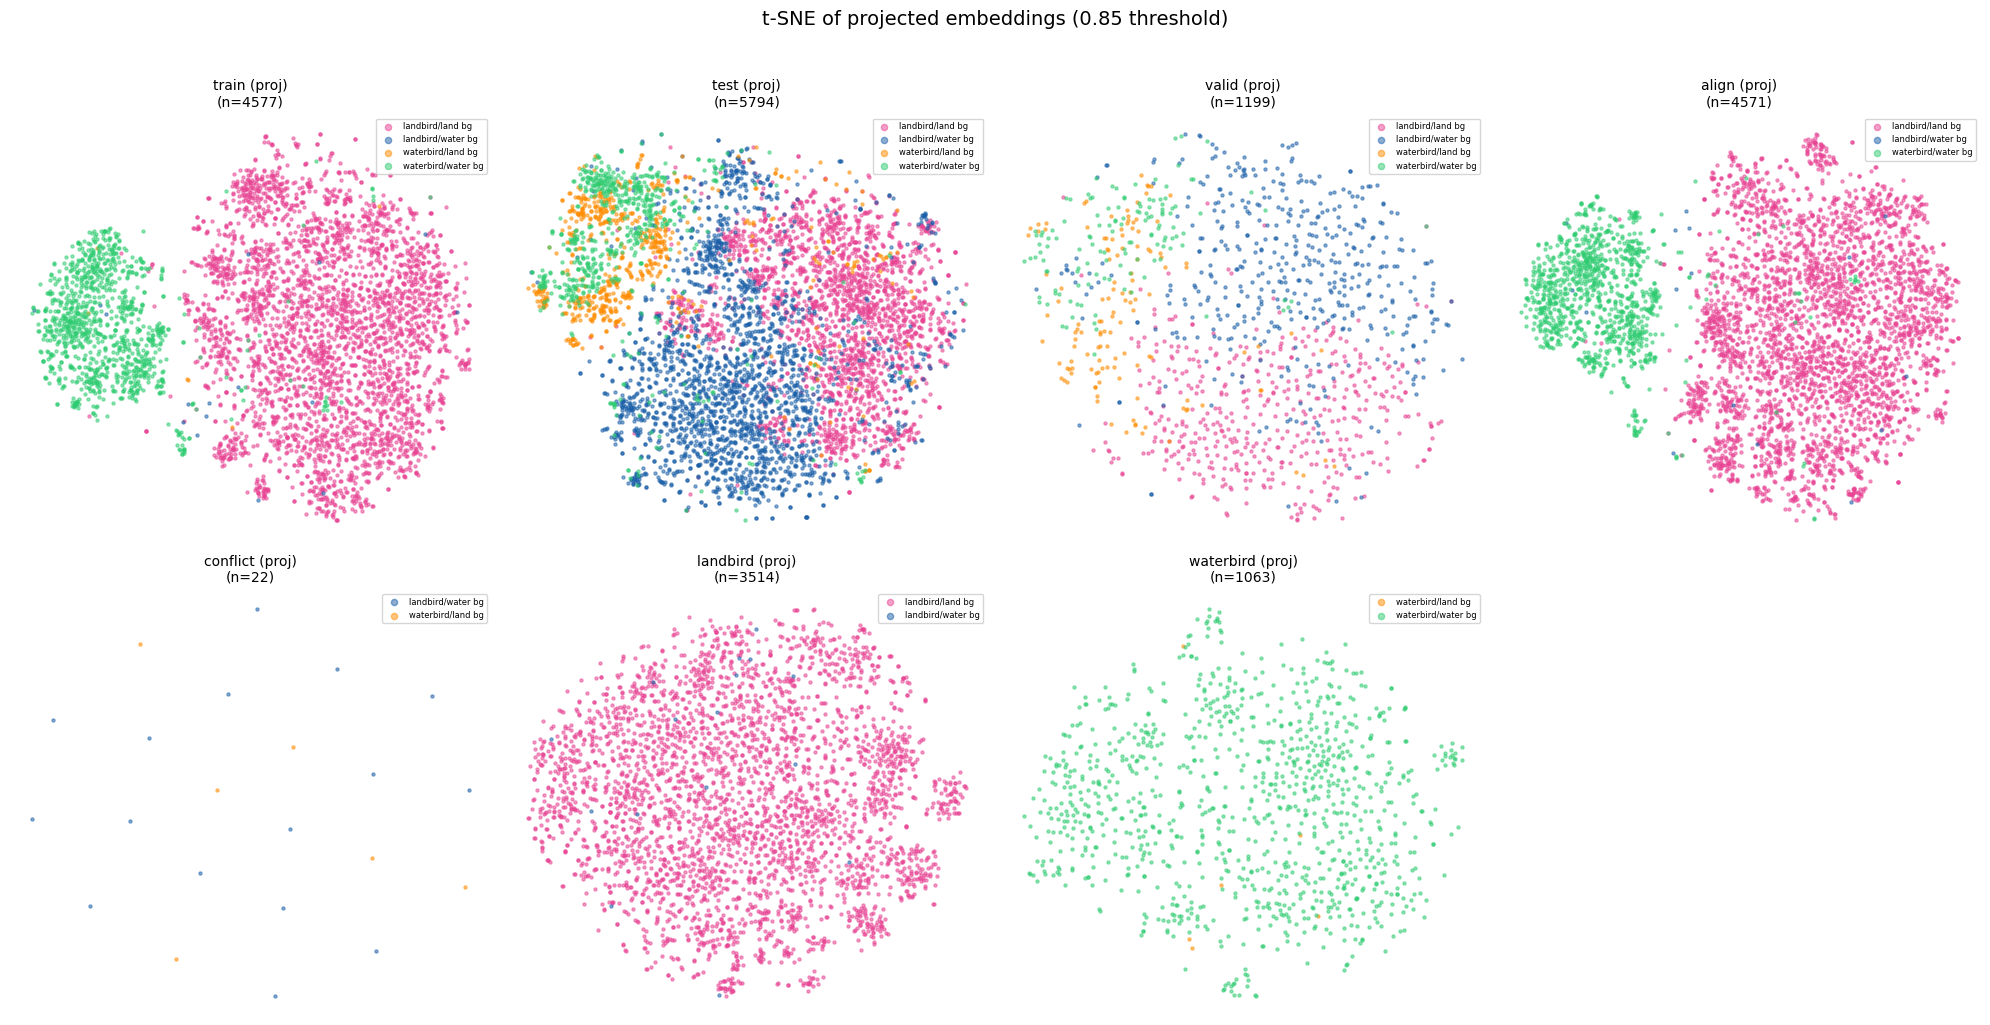

In [162]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import os
os.makedirs("0.5pct/push_pull/tsne", exist_ok=True)

group_names = {0: "landbird/land bg",  1: "landbird/water bg",
               2: "waterbird/land bg", 3: "waterbird/water bg"}
colors      = {0: "#E84393", 1: "#1A5FA8", 2: "#FF8C00", 3: "#2ECC71"}

class LinearDebias(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.W = nn.Parameter(torch.eye(dim))
    def forward(self, x):
        out = x @ self.W
        return out / out.norm(dim=-1, keepdim=True)

device     = "cuda"
model_head = LinearDebias().to(device)
model_head.load_state_dict(torch.load("0.5pct/push_pull/Projection_heads/projection_head_push_pull(0.85).pt"))
model_head.eval()

def project(embs, batch_size=512):
    out = []
    with torch.no_grad():
        for i in range(0, len(embs), batch_size):
            batch = embs[i:i+batch_size].to(device)
            out.append(model_head(batch).cpu())
    return torch.cat(out, dim=0).numpy()

splits = [
    ("train (proj)",     project(train_embs),    train_labels,    train_groups),
    ("test (proj)",      project(test_embs),      test_labels,     test_groups),
    ("valid (proj)",     project(valid_embs),     valid_labels,    valid_groups),
    ("align (proj)",     project(align_embs),     align_labels,    align_groups),
    ("conflict (proj)",  project(conflict_embs),  conflict_labels, conflict_groups),
    ("landbird (proj)",  project(embs_0),         labels_0,        groups_0),
    ("waterbird (proj)", project(embs_1),         labels_1,        groups_1),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.flatten()

for ax, (name, embs, label, background) in zip(axes_flat, splits):  # ← axes_flat
    group = label * 2 + background
    n     = len(embs)

    print(f"Running t-SNE for {name} ({n} points)...")
    tsne = TSNE(n_components=2, perplexity=min(30, n - 1), random_state=42, max_iter=1000)
    e2d  = tsne.fit_transform(embs)

    for g, gname in group_names.items():
        mask = group == g
        if mask.sum() == 0:
            continue
        ax.scatter(e2d[mask, 0], e2d[mask, 1],
                   c=colors[g], label=gname, s=5, alpha=0.5)

    ax.set_title(f"{name}\n(n={n})", fontsize=10)
    ax.legend(fontsize=6, markerscale=2)
    ax.axis("off")

# Hide unused 8th subplot (7 splits, 8 axes)
axes_flat[-1].set_visible(False)

plt.suptitle("t-SNE of projected embeddings (0.85 threshold)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("0.5pct/push_pull/tsne/tsne_projected_all_splits(0.85).png", dpi=150, bbox_inches="tight")
print("Saved!")

In [163]:
model_head.eval()

splits = [
    ("train",     train_embs, train_labels, train_groups),
    ("test",      test_embs,  test_labels,  test_groups),
    ("valid",     valid_embs, valid_labels, valid_groups),
    ("align",     align_embs,    align_labels,    align_groups),
    ("conflict",  conflict_embs, conflict_labels, conflict_groups),
    ("landbird",  embs_0,     labels_0,     groups_0),
    ("waterbird", embs_1,     labels_1,     groups_1),
]

for name, embs_tensor, label, background in splits:
    n     = len(embs_tensor)
    group = label * 2 + background

    orig = embs_tensor.cpu().numpy()
    proj = project(embs_tensor)

    print(f"t-SNE original  {name} ({n} points)...")
    orig_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(orig)

    print(f"t-SNE projected {name} ({n} points)...")
    proj_2d = TSNE(n_components=2, perplexity=min(30, n-1), random_state=42, max_iter=1000).fit_transform(proj)

    # Side by side — left original, right projected
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, e2d, title in [
        (axes[0], orig_2d, f"{name} — original (n={n})"),
        (axes[1], proj_2d, f"{name} — projected (n={n})"),
    ]:
        for g, gname in group_names.items():
            mask = group == g
            if mask.sum() == 0:
                continue
            ax.scatter(e2d[mask, 0], e2d[mask, 1],
                       c=colors[g], label=gname, s=5, alpha=0.6)
        ax.set_title(title, fontsize=12)
        ax.axis("off")

    # Shared legend at top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4,
               bbox_to_anchor=(0.5, 1.05), fontsize=9, markerscale=3)

    plt.tight_layout()
    plt.savefig(f"0.5pct/push_pull/tsne/tsne_{name}_orig_vs_proj(0.85).png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved tsne_{name}_orig_vs_proj(0.85).png")

t-SNE original  train (4577 points)...
t-SNE projected train (4577 points)...
Saved tsne_train_orig_vs_proj(0.85).png
t-SNE original  test (5794 points)...
t-SNE projected test (5794 points)...
Saved tsne_test_orig_vs_proj(0.85).png
t-SNE original  valid (1199 points)...
t-SNE projected valid (1199 points)...
Saved tsne_valid_orig_vs_proj(0.85).png
t-SNE original  align (4571 points)...
t-SNE projected align (4571 points)...
Saved tsne_align_orig_vs_proj(0.85).png
t-SNE original  conflict (22 points)...
t-SNE projected conflict (22 points)...
Saved tsne_conflict_orig_vs_proj(0.85).png
t-SNE original  landbird (3514 points)...
t-SNE projected landbird (3514 points)...
Saved tsne_landbird_orig_vs_proj(0.85).png
t-SNE original  waterbird (1063 points)...
t-SNE projected waterbird (1063 points)...
Saved tsne_waterbird_orig_vs_proj(0.85).png
